# EUROPLANET / EPEC Research Lab — **From Signal to Scientific Decision**

### A 90-minute planetary-science practical on representations, AI, and relational information

**Scientific path**

\[
\mathrm{PLATO\text{-}like\ light\ curves}
\rightarrow \mathrm{BLS}
\rightarrow \mathrm{PANOPTICON\text{-}inspired\ event\ map}
\rightarrow \mathrm{PLATO\ multi\text{-}diagnostic\ vetter}
\rightarrow \mathrm{ConvCNP}
\rightarrow \mathrm{AttnLNP}
\rightarrow \mathrm{follow\!-\!up\ decision}.
\]

Alongside that PLATO chain, we use **official NASA ExoMiner++ on real TESS/SPOC cases as a survey-specific case study**. We transfer the **vetting philosophy**, not the trained TESS model, to the PLATO-like classroom data.

The purpose is **not** to ask which algorithm is “best.” Each method preserves a different relation in the data and answers a different scientific question.

### Learning outcomes
By the end, you should be able to:
1. explain why a strong detection statistic is not automatically a planet detection;
2. distinguish **periodic evidence**, **local event morphology**, and **multi-diagnostic vetting**;
3. explain why a production model such as ExoMiner++ cannot be transferred fairly across surveys without matching its expected representation;
4. build an explicitly labelled **PLATO classroom vetter** that fuses several permitted diagnostics without using simulation-truth columns as inputs;
5. explain why global CNP pooling underfits localized events and compare how **ConvCNP** and a full **Attentive Latent Neural Process (AttnLNP)** preserve locality, target-context relations, and latent uncertainty;
6. use uncertainty and disagreement to choose follow-up observations;
7. state clearly what is **official code**, what is a **classroom reimplementation**, and what is a **conceptual extension**.


## ⏱ 90-minute schedule

| Time | Activity | Scientific question |
|---|---|---|
| 0–6 min | Mission, provenance, setup | What information reaches each algorithm? |
| 6–14 min | **Data inspection — observe before you infer** | What exactly is in the simulation, and which columns are evidence versus truth? |
| 14–26 min | **Exercise 1 — BLS** | When does periodic evidence become a false positive? |
| 26–44 min | **Exercise 2 — PANOPTICON-inspired U-Net3+** | Can local morphology rescue or reject BLS candidates? |
| 44–49 min | **Exercise 3A — official NASA ExoMiner++ case study** | Why is production vetting representation- and survey-specific? |
| 49–57 min | **Exercise 3B — PLATO multi-diagnostic vetter** | What happens when we transfer the vetting philosophy, not the TESS model? |
| 57–77 min | **Exercise 4 — ConvCNP + full AttnLNP** | What is preserved by locality, attention, and a latent path? |
| 77–87 min | **Exercise 5 — Mission board** | Which five objects deserve scarce follow-up? |
| 87–90 min | Exit ticket | What should a scientifically useful representation preserve? |

### Provenance — say this explicitly in class

| Component | What this notebook uses |
|---|---|
| BLS | precomputed results from the student PLATO-like simulation pipeline |
| PANOPTICON | **PANOPTICON-inspired** 1-D U-Net3+ classroom reimplementation; **not** Vivien et al. author code or weights |
| official ExoMiner++ | official NASA ExoMiner pipeline/output on TESS/SPOC products; **not applied directly to the PLATO simulation** |
| PLATO multi-diagnostic vetter | small classroom logistic-fusion model using permitted PLATO diagnostics; **inspired by the ExoMiner philosophy, not ExoMiner++** |
| ConvCNP | compact classroom ConvCNP-style implementation with set convolution + CNN; not author code |
| AttnLNP | compact classroom **full latent + attentive architecture**: deterministic target-to-context attention, context prior, context+target posterior, reparameterized latent sampling, and KL-regularized variational training; **not the authors' released implementation** |

This distinction is part of scientific reproducibility.


✓ EUROPLANET lab environment ready
  Python kernel : /opt/anaconda3/envs/europlanet-lab/bin/python
  PyTorch       : 2.13.0
  Working dir   : /Users/angelicakovacevic/Downloads/europlanet-student-test_exominer/student
  Project root  : /Users/angelicakovacevic/Downloads/europlanet-student-test_exominer
  Cases loaded  : 1457
  BLS quiet-star 95th-percentile threshold = 1.619e+04


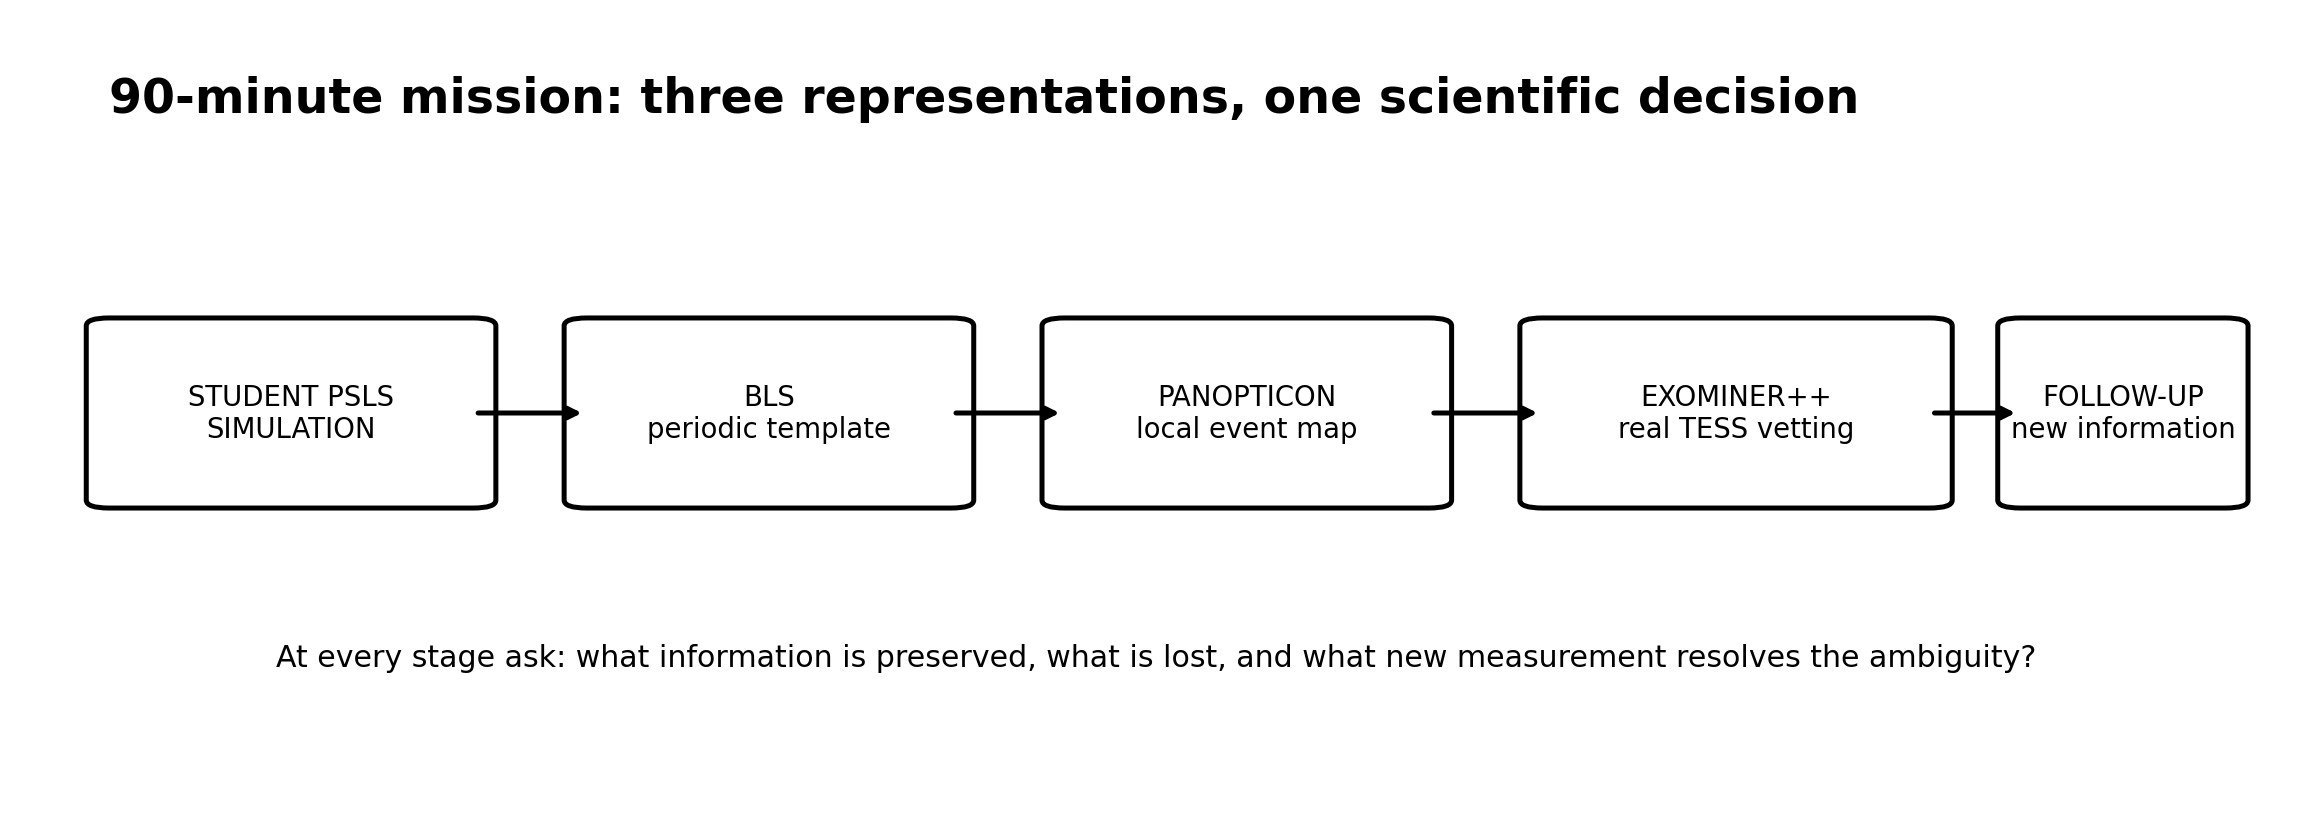

,class,meaning,N
0,0,"Quiet star, no planet",372
1,1,"Active star, no planet",358
2,2,Planet + mild activity,373
3,3,Planet + strong activity,354


In [1]:
# === PRE-FLIGHT: robust project discovery + environment check ===

from pathlib import Path
import sys, importlib.util, json, subprocess, shutil, math, time as _time

_REQUIRED = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
    'torch': 'torch',
}
_missing = [pip_name for module_name, pip_name in _REQUIRED.items()
            if importlib.util.find_spec(module_name) is None]

if _missing:
    raise ModuleNotFoundError(
        "Missing package(s) in the CURRENT Jupyter kernel: " + ", ".join(_missing) + "\n\n"
        "Active Python: " + sys.executable + "\n\n"
        "Recommended Anaconda setup:\n"
        "  conda env create -f environment.yml\n"
        "  conda activate europlanet-lab\n"
        "  python -m ipykernel install --user --name europlanet-lab --display-name 'EUROPLANET Lab'\n"
        "Then choose the 'EUROPLANET Lab' kernel in Jupyter."
    )

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import roc_auc_score, confusion_matrix, roc_curve
from IPython.display import Image, display as ipydisplay, display

def _find_lab_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents, start / 'Europlanet_ResearchLab_90min']
    for c in candidates:
        if ((c / 'europlanet_lab_utils.py').exists()
                and (c / 'data').is_dir()
                and (c / 'models').is_dir()
                and (c / 'assets').is_dir()):
            return c
    raise FileNotFoundError(
        "Cannot locate the EUROPLANET lab package root.\n"
        f"Current working directory: {start}\n"
        "Expected europlanet_lab_utils.py together with data/, models/, and assets/."
    )

ROOT = _find_lab_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA_DIR  = ROOT / 'data'
MODEL_DIR = ROOT / 'models'
ASSET_DIR = ROOT / 'assets'
EXO_DIR   = ROOT / 'exominer_official'

from europlanet_lab_utils import *

meta, bls, pan, df, BLS_THR = load_tables(ROOT)

np.random.seed(7)
torch.manual_seed(7)

print('✓ EUROPLANET lab environment ready')
print('  Python kernel :', sys.executable)
print('  PyTorch       :', torch.__version__)
print('  Working dir   :', Path.cwd().resolve())
print('  Project root  :', ROOT)
print(f'  Cases loaded  : {len(meta)}')
print(f'  BLS quiet-star 95th-percentile threshold = {BLS_THR:.4g}')

_lab_map = ASSET_DIR / 'lab_map.png'
if _lab_map.exists():
    ipydisplay(Image(filename=str(_lab_map), width=900))

display(pd.DataFrame({
    'class': [0, 1, 2, 3],
    'meaning': [CLASS_LABELS[i] for i in range(4)],
    'N': [int((meta.label == i).sum()) for i in range(4)]
}))

## 0. The information chain — **6 min**

We never classify a planet “directly.” We classify a representation produced by a measurement and compression chain:

\[
S \xrightarrow{H} X \xrightarrow{\text{representation}} Z
\xrightarrow{\text{decision rule}} \hat Y .
\]

For this practical, think of:

- \(S\): stellar + planetary physical state;
- \(H\): cadence, noise, observing window, instrumental response;
- \(X\): measured light curve / diagnostic products;
- \(Z\): BLS statistic, event map, diagnostic embedding, or NP context representation;
- \(\hat Y\): detection, vetting probability, predictive distribution, or observing decision.

### Warm-up question
Two classifiers can receive the **same photons** and disagree because they compress them differently.  
**Name one relation that BLS preserves and one relation it discards.**

> **YOUR ANSWER:**  
>

# Data inspection — **observe before you infer** **[8 min]**

Before fitting anything, inspect the measurement products and identify what is **observable**, what is **derived**, and what is available only because this is a simulation.

This package contains three different data layers:

1. **Population metadata — 1,457 simulated systems.** Stellar/activity parameters plus injected-planet truth where a planet exists.
2. **BLS results — 1,457 rows.** Outputs of the baseline transit-search analysis, joined to the metadata for evaluation.
3. **Local event windows — 100 × 512 samples.** A balanced subset used for the PANOPTICON-inspired and Neural-Process exercises.

> **Important:** the simulation truth columns are for evaluation and teaching. They are **not legitimate inference features** for a real blind search.

### Task D0.1 — inspect structure before values

Before running the next cell, predict which columns would cause **target leakage** if supplied to a transit classifier.

> **YOUR PREDICTION:**  
>


In [2]:
# === DATA INSPECTION 1: What objects and variables do we actually have? ===

local_windows = np.load(DATA_DIR / 'panopticon_eval_windows.npz')

print('Population metadata shape :', meta.shape)
print('Merged analysis table     :', df.shape)
print('Local-event window array  :', local_windows['flux'].shape)
print('Window keys               :', local_windows.files)

variable_dictionary = pd.DataFrame([
    ['file_id', 'identifier', 'bookkeeping', 'yes'],
    ['teff, logg, star_mass_msun, star_radius_rsun', 'stellar context', 'simulated/estimated physical metadata', 'context-dependent'],
    ['sigma_ppm, act_rms, rotation_period_days', 'noise/activity context', 'measurable/estimable nuisance physics', 'yes, if available'],
    ['planet_present, label', 'class truth', 'simulation truth', 'NO — target leakage'],
    ['planet_period_days, planet_radius_earth, transit_depth_ppm', 'injected planet truth', 'simulation truth for planet cases', 'NO in a blind search'],
    ['bls_period, bls_power, bls_depth_ppm', 'BLS outputs', 'derived statistics', 'yes for downstream vetting'],
    ['panopticon_event_score', 'classroom event-detector output', 'derived statistic', 'yes for downstream comparison'],
    ['mask in local_windows', 'true transit sample mask', 'simulation truth', 'NO — evaluation/training construction only'],
], columns=['variable(s)', 'role', 'provenance', 'valid blind-search input?'])

display(variable_dictionary)

preview_cols = [
    'file_id','label','activity_class','teff','logg','sigma_ppm','act_rms',
    'rotation_period_days','planet_present','planet_period_days',
    'planet_radius_earth','transit_depth_ppm'
]
display(meta[preview_cols].head(8))

# Missing values can be structural, not bad data: no-planet systems do not have planet parameters.
missing = (meta[preview_cols].isna().mean()*100).round(1).to_frame('% NaN')
display(missing)


Population metadata shape : (1457, 38)
Merged analysis table     : (1457, 60)
Local-event window array  : (100, 512)
Window keys               : ['time', 'flux', 'mask', 'file_id', 'label']


,variable(s),role,provenance,valid blind-search input?
0,file_id,identifier,bookkeeping,yes
1,"teff, logg, star_mass_msun, star_radius_rsun",stellar context,simulated/estimated physical metadata,context-dependent
2,"sigma_ppm, act_rms, rotation_period_days",noise/activity context,measurable/estimable nuisance physics,"yes, if available"
3,"planet_present, label",class truth,simulation truth,NO — target leakage
4,"planet_period_days, planet_radius_earth, trans...",injected planet truth,simulation truth for planet cases,NO in a blind search
5,"bls_period, bls_power, bls_depth_ppm",BLS outputs,derived statistics,yes for downstream vetting
6,panopticon_event_score,classroom event-detector output,derived statistic,yes for downstream comparison
7,mask in local_windows,true transit sample mask,simulation truth,NO — evaluation/training construction only


,file_id,label,activity_class,teff,logg,sigma_ppm,act_rms,rotation_period_days,planet_present,planet_period_days,planet_radius_earth,transit_depth_ppm
0,1003,2,mild,6373.3,4.310,10.54,45.443410,23.34,1,3.3447,1.26852,88.562464
1,1359,3,strong,6310.6,4.284,107.21,228.019606,18.23,1,16.6958,2.85395,426.304760
2,713,1,strong,5639.7,4.506,73.23,246.061123,16.15,0,NaN,NaN,NaN
3,316,0,mild,6162.2,4.528,12.11,42.579085,34.36,0,NaN,NaN,NaN
4,1301,3,strong,5282.6,4.317,92.52,227.908634,15.37,1,12.6726,1.43825,122.001849
5,345,0,mild,6006.9,4.327,5.65,33.699516,20.30,0,NaN,NaN,NaN
6,442,1,strong,5925.0,4.525,90.27,148.675622,12.34,0,NaN,NaN,NaN
7,787,2,mild,5312.6,4.526,13.90,62.207262,26.74,1,23.0620,1.46938,245.792937


,% NaN
file_id,0.0
label,0.0
activity_class,0.0
teff,0.0
logg,0.0
sigma_ppm,0.0
act_rms,0.0
rotation_period_days,0.0
planet_present,0.0
planet_period_days,50.1


### Task D0.2 — distinguish missingness from physics

Answer briefly:

1. Why are `planet_period_days`, `planet_radius_earth`, and `transit_depth_ppm` missing for some rows? Is that ordinary missing-data noise?
2. Name **three columns** you must never give a blind planet detector as inputs because they encode the answer.
3. Which quantities are **measurements/derived statistics**, and which are **simulation truth**?

> **YOUR ANSWER:**  
>


,class,meaning,N,median sigma_ppm,median activity RMS [ppm],median rotation [d],planet fraction,median transit depth [ppm]
0,0,"Quiet star, no planet",372,14.8,47.2,27.5,0%,nan
1,1,"Active star, no planet",358,63.0,221.2,15.5,0%,nan
2,2,Planet + mild activity,373,14.4,66.6,28.1,100%,249.1
3,3,Planet + strong activity,354,61.5,238.9,15.4,100%,278.4


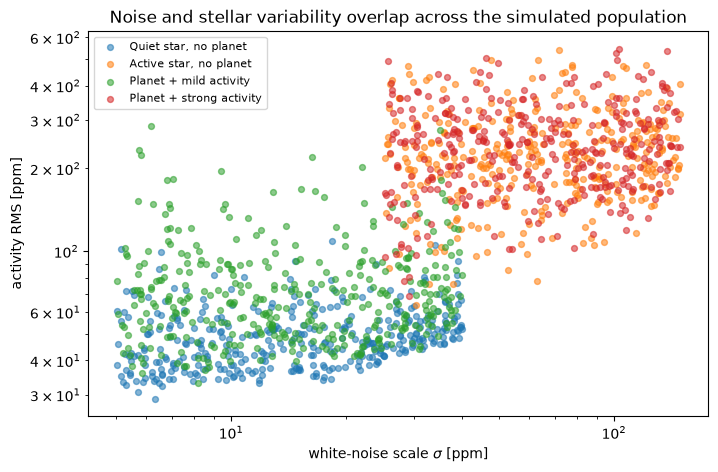

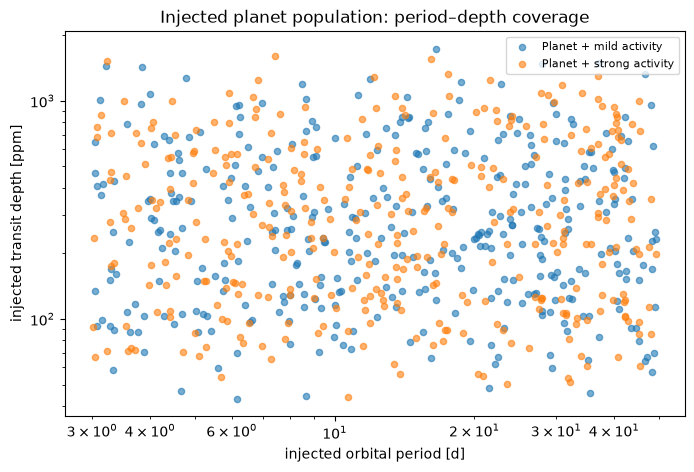

In [3]:
# === DATA INSPECTION 2: Are the four physical classes actually separable? ===

class_summary = []
for c in range(4):
    s = meta[meta.label == c]
    class_summary.append({
        'class': c,
        'meaning': CLASS_LABELS[c],
        'N': len(s),
        'median sigma_ppm': s.sigma_ppm.median(),
        'median activity RMS [ppm]': s.act_rms.median(),
        'median rotation [d]': s.rotation_period_days.median(),
        'planet fraction': s.planet_present.mean(),
        'median transit depth [ppm]': (s.loc[s.planet_present == 1, 'transit_depth_ppm'].median() if (s.planet_present == 1).any() else np.nan),
    })

display(pd.DataFrame(class_summary).style.format({
    'median sigma_ppm':'{:.1f}',
    'median activity RMS [ppm]':'{:.1f}',
    'median rotation [d]':'{:.1f}',
    'planet fraction':'{:.0%}',
    'median transit depth [ppm]':'{:.1f}'
}))

fig, ax = plt.subplots(figsize=(8,5))
for c in range(4):
    s = meta[meta.label == c]
    ax.scatter(s.sigma_ppm, s.act_rms, s=18, alpha=.55, label=CLASS_LABELS[c])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('white-noise scale $\\sigma$ [ppm]')
ax.set_ylabel('activity RMS [ppm]')
ax.set_title('Noise and stellar variability overlap across the simulated population')
ax.legend(fontsize=8)
plt.show()

planet_meta = meta[meta.planet_present == 1].copy()
fig, ax = plt.subplots(figsize=(8,5))
for c in [2,3]:
    s = planet_meta[planet_meta.label == c]
    ax.scatter(s.planet_period_days, s.transit_depth_ppm,
               s=20, alpha=.6, label=CLASS_LABELS[c])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('injected orbital period [d]')
ax.set_ylabel('injected transit depth [ppm]')
ax.set_title('Injected planet population: period–depth coverage')
ax.legend(fontsize=8)
plt.show()


### Task D0.3 — inspect overlap, not only averages

Look at the plots rather than only the medians.

1. Do activity and white-noise level cleanly separate the classes?
2. Could a classifier obtain apparently high accuracy by learning the **simulation design** rather than transit physics?
3. What split would you use to test that possibility: random rows, stellar-regime holdout, activity-regime holdout, or something else?

> **YOUR ANSWER:**  
>


N windows : 100
samples/window: 512
class counts: {0: 25, 1: 25, 2: 25, 3: 25}
median local cadence = 0.009785 d = 14.09 min
5–95% cadence range  = 14.09–14.09 min


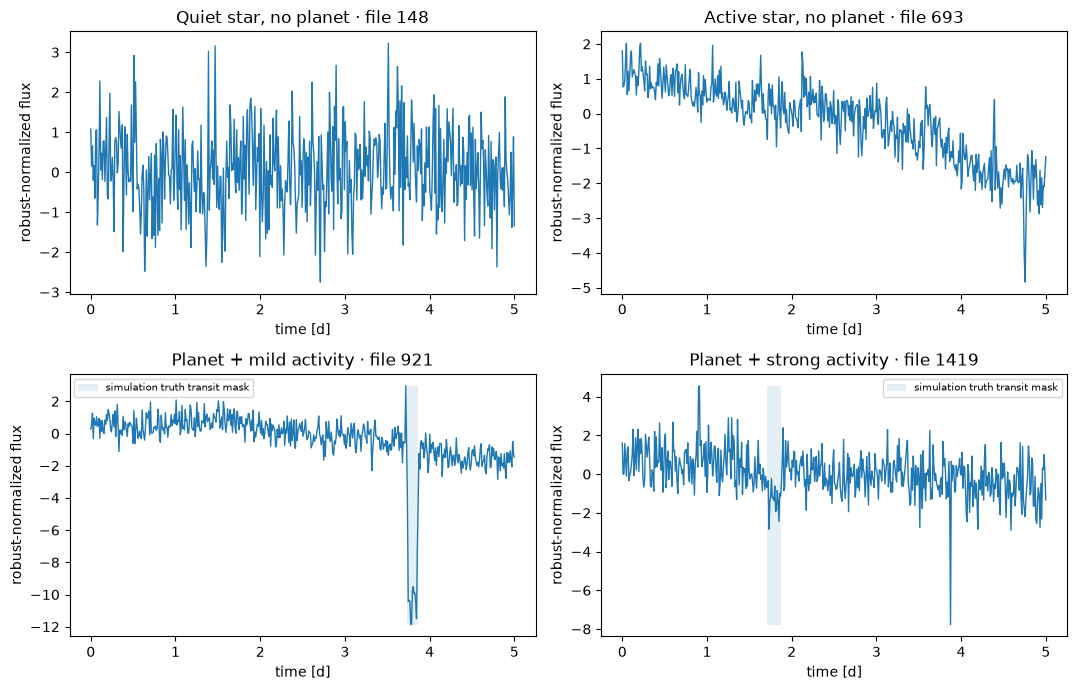

Planet-window transit duty fraction:
  median = 0.0380859375
  range  = (0.021484375, 0.07421875)


In [4]:
# === DATA INSPECTION 3: Look at the actual local light-curve representation ===

z0 = local_windows
print('N windows :', len(z0['file_id']))
print('samples/window:', z0['flux'].shape[1])
print('class counts:', {int(c): int((z0['label']==c).sum()) for c in np.unique(z0['label'])})

# Cadence inspection. These are local windows, so inspect dt rather than assuming it.
dt = np.diff(z0['time'], axis=1).ravel()
dt = dt[np.isfinite(dt) & (dt > 0)]
print(f'median local cadence = {np.median(dt):.6f} d = {np.median(dt)*24*60:.2f} min')
print(f'5–95% cadence range  = {np.percentile(dt,5)*24*60:.2f}–{np.percentile(dt,95)*24*60:.2f} min')

fig, axes = plt.subplots(2, 2, figsize=(11,7), sharex=False)
axes = axes.ravel()
for ax, c in zip(axes, range(4)):
    ids = np.where(z0['label'] == c)[0]
    q = ids[len(ids)//2]
    t = z0['time'][q]
    f = z0['flux'][q]
    truth = z0['mask'][q].astype(bool)
    ax.plot(t, f, lw=1)
    if truth.any():
        ax.fill_between(t, np.nanmin(f), np.nanmax(f), where=truth, alpha=.12,
                        label='simulation truth transit mask')
    ax.set_title(f"{CLASS_LABELS[c]} · file {int(z0['file_id'][q])}")
    ax.set_xlabel('time [d]')
    ax.set_ylabel('robust-normalized flux')
    if truth.any(): ax.legend(fontsize=7)
plt.tight_layout()
plt.show()

# How much of each local window is actually transit for planet cases?
planet_win = z0['label'] >= 2
transit_fraction = z0['mask'][planet_win].mean(axis=1)
print('Planet-window transit duty fraction:')
print('  median =', float(np.median(transit_fraction)))
print('  range  =', (float(np.min(transit_fraction)), float(np.max(transit_fraction))))


### Task D0.4 — representation audit

1. What information has already been lost when a long irregular light curve is reduced to a 512-sample local window?
2. Why is the **truth transit mask** useful for evaluation but scientifically invalid as a blind-search input?
3. Pick one displayed window. What could fool a box model? What could fool a local morphology model?
4. Does inspecting four examples establish generalization? What population-level check would you demand next?

> **YOUR ANSWER:**  
>


# Exercise 1 — BLS: a detection statistic is not “the truth” **[12 min]**

The baseline represented in these tables used a classical transit-search logic: detrending/aggregation followed by **Box Least Squares**. The decision threshold is set from the quiet no-planet population.

A useful detection statistic can still be confounded if an unmodelled process projects strongly onto its template family.

### Task 1A
Measure how often BLS crosses the quiet-star threshold in each physical class.

### Prediction before running the cell
Which class should generate the largest **false-positive rate**, and why?

> **YOUR PREDICTION:**  
>

,class,meaning,N,BLS above threshold,period match,recovered
0,0,"Quiet star, no planet",372,5.1%,nan%,nan%
1,1,"Active star, no planet",358,90.5%,nan%,nan%
2,2,Planet + mild activity,373,98.4%,96.2%,96.0%
3,3,Planet + strong activity,354,100.0%,89.5%,89.5%


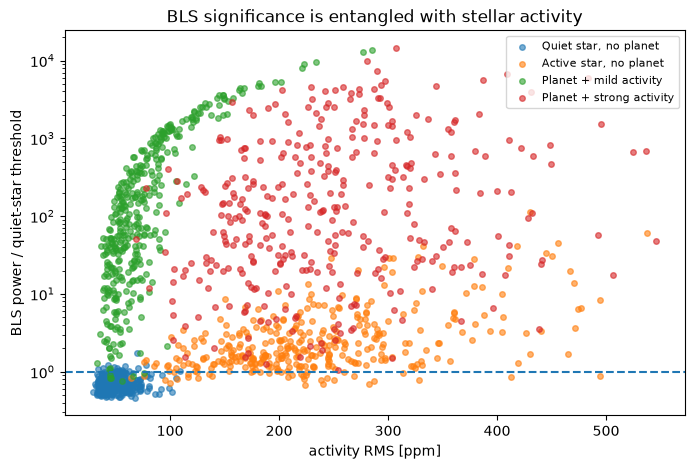

In [5]:
rows = []
for c in range(4):
    s = df[df.label == c]
    rows.append({
        'class': c,
        'meaning': CLASS_LABELS[c],
        'N': len(s),
        'BLS above threshold': s.bls_flag_recalc.mean(),
        'period match': np.nan if c < 2 else s.period_match.mean(),
        'recovered': np.nan if c < 2 else (s.bls_flag_recalc & s.period_match).mean()
    })

audit = pd.DataFrame(rows)
display(audit.style.format({
    'BLS above threshold': '{:.1%}',
    'period match': '{:.1%}',
    'recovered': '{:.1%}'
}))

fig, ax = plt.subplots(figsize=(8,5))
for c in range(4):
    s = df[df.label == c]
    ax.scatter(s.act_rms, s.bls_power_ratio, s=16, alpha=.6, label=CLASS_LABELS[c])
ax.axhline(1, ls='--')
ax.set_yscale('log')
ax.set_xlabel('activity RMS [ppm]')
ax.set_ylabel('BLS power / quiet-star threshold')
ax.legend(fontsize=8)
ax.set_title('BLS significance is entangled with stellar activity')
plt.show()

### Task 1B — interpretation

Answer in **2–3 sentences**:

1. Why is “high BLS power” not sufficient evidence for a planet?
2. What information does a period search deliberately compress away?
3. Does changing the threshold solve the activity problem, or merely move the sensitivity–specificity trade-off?

> **YOUR ANSWER:**  
>

# Exercise 2 — PANOPTICON-inspired U-Net3+: change the question **[18 min]**

Vivien et al. developed PANOPTICON for **single-event transit detection in unfiltered PLATO-like light curves**. Its key conceptual shift is:

\[
\text{“What periodic box fits the whole light curve?”}
\quad\longrightarrow\quad
\text{“Where is transit-like morphology?”}
\]

The published method uses the 1-D U-Net family and reports U-Net3+ as the strongest variant.

> **Provenance warning:** the model below is a **classroom PANOPTICON-inspired U-Net3+ reimplementation following the published design**. It is **not the authors' original code and not their released weights**.

### Task 2A
Inspect two local event maps: a planet in strong activity and an active no-planet star.

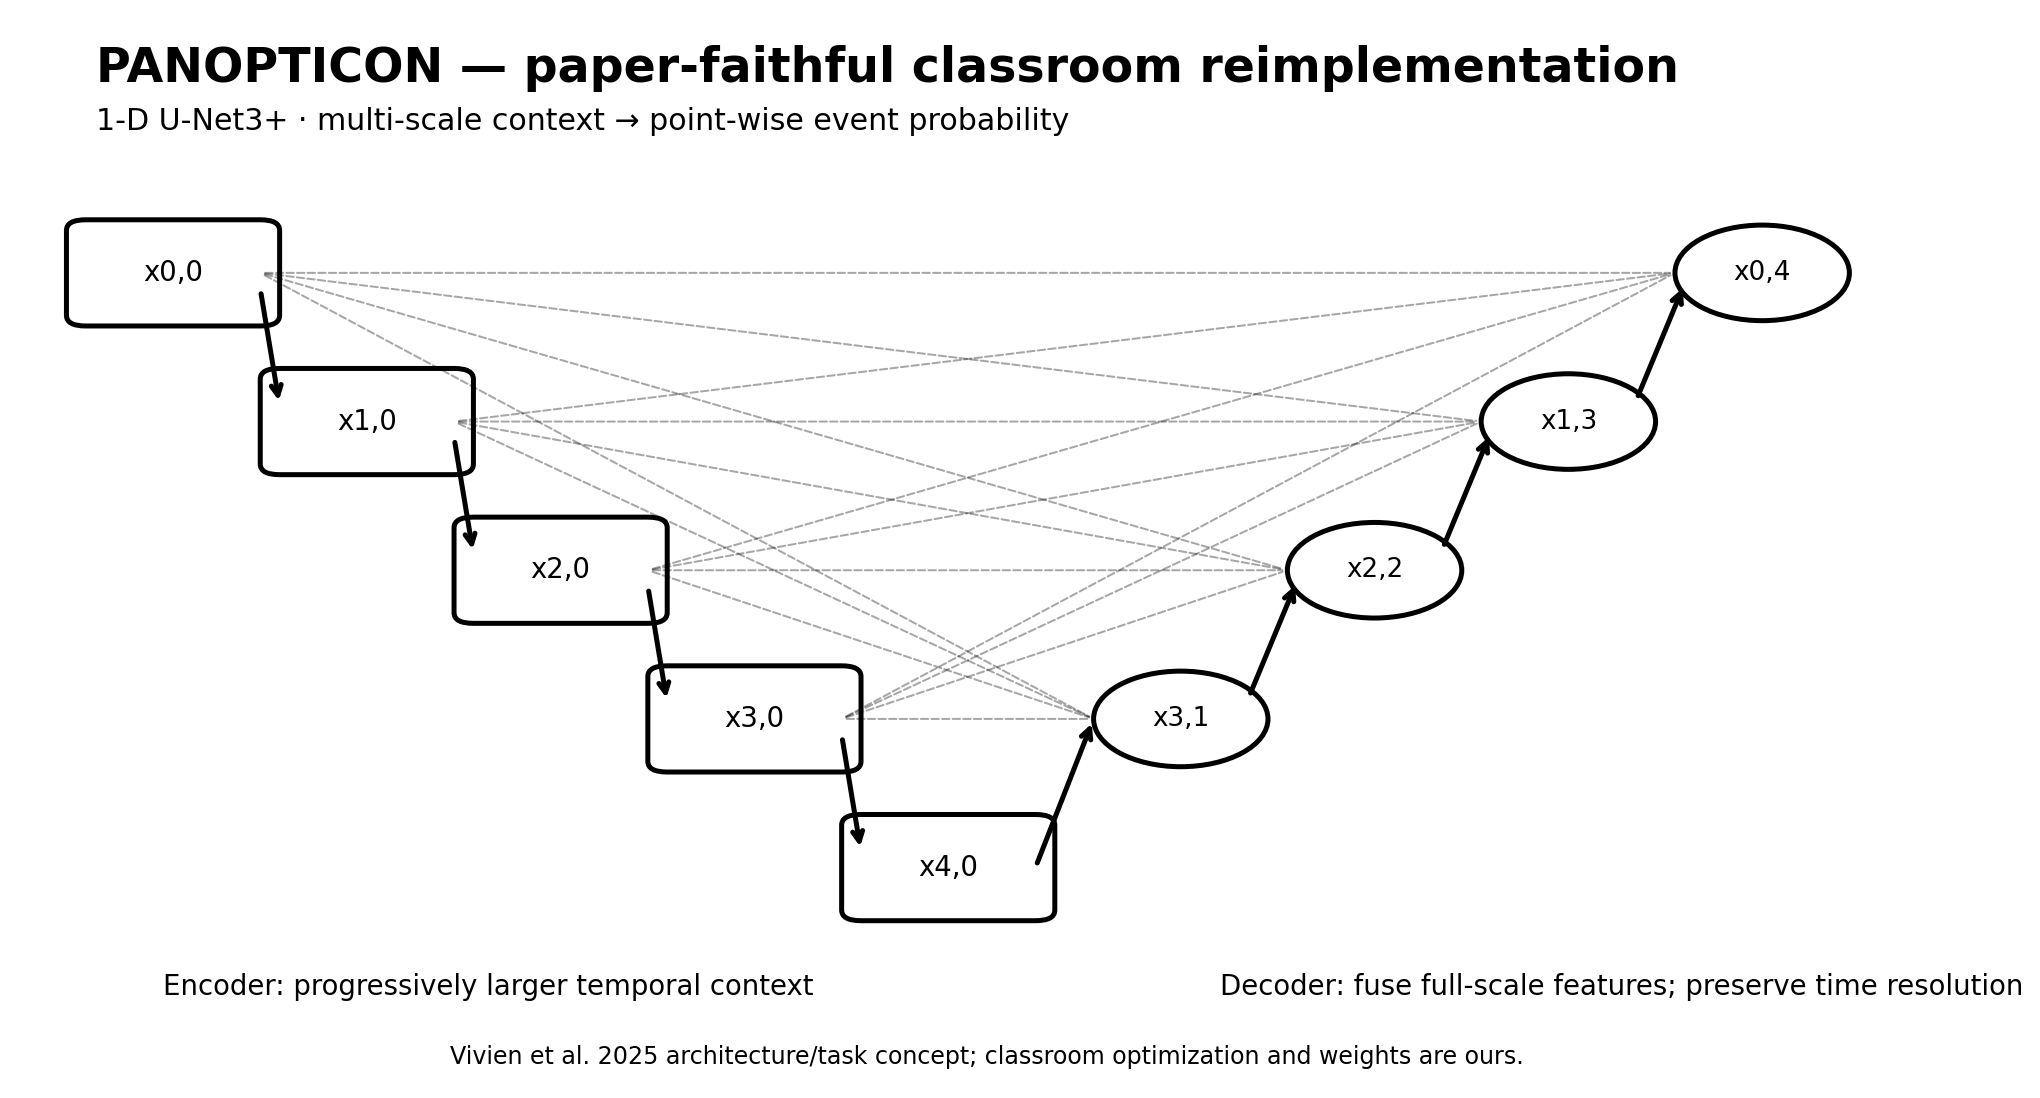

Classroom model parameters: 132,553
Classroom training history: [{'epoch': 1, 'loss': 0.5863020743642534, 'point_auc': 0.9902213206211292}, {'epoch': 2, 'loss': 0.46552795342036657, 'point_auc': 0.9900867739911268}, {'epoch': 3, 'loss': 0.39672146609851294, 'point_auc': 0.991096301671512}, {'epoch': 4, 'loss': 0.3301013835838863, 'point_auc': 0.9940527046487375}, {'epoch': 5, 'loss': 0.26689387517316, 'point_auc': 0.9919048067396027}]
PROVENANCE: PANOPTICON-inspired classroom reimplementation; not author code/weights.


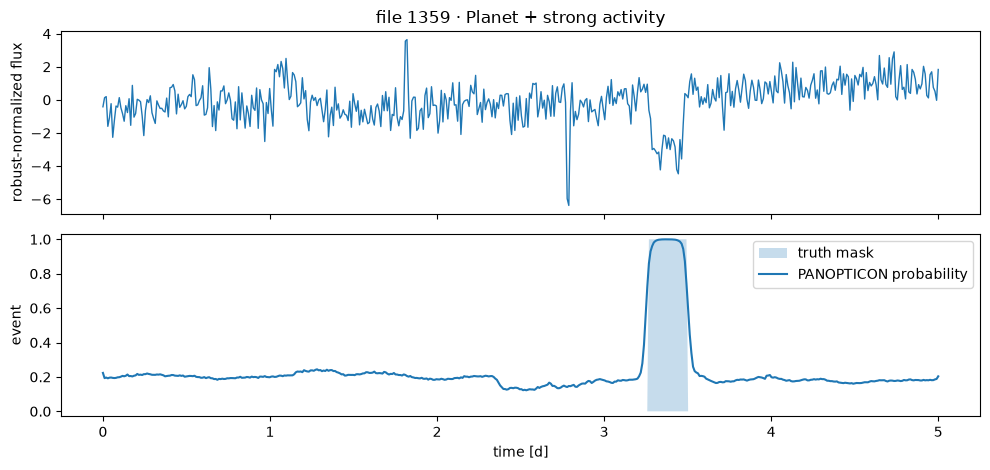

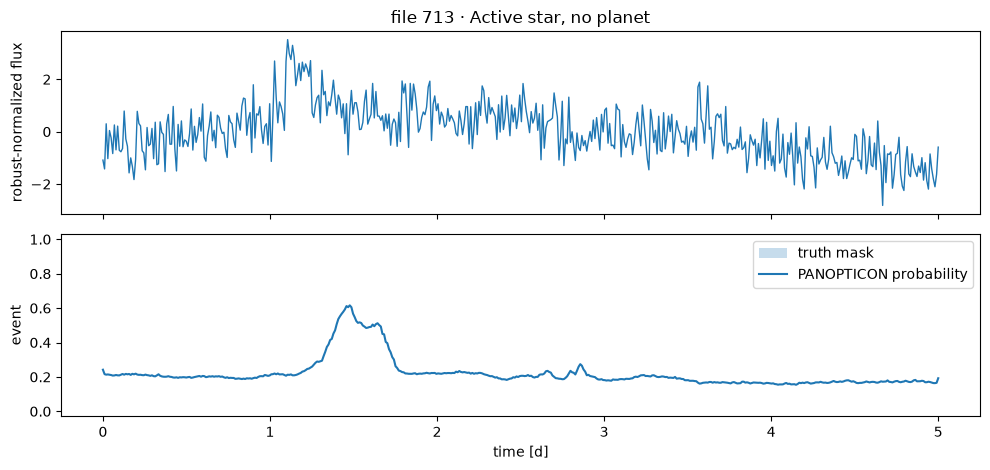

In [6]:
_pan_arch = ASSET_DIR / 'panopticon_unet3plus.png'
if _pan_arch.exists():
    ipydisplay(Image(filename=str(_pan_arch), width=900))

model, ck = load_panopticon(ROOT)
print('Classroom model parameters:', f"{sum(p.numel() for p in model.parameters()):,}")
print('Classroom training history:', ck['history'])
print('PROVENANCE: PANOPTICON-inspired classroom reimplementation; not author code/weights.')

_pan_eval = DATA_DIR / 'panopticon_eval_windows.npz'
z = np.load(_pan_eval)

choices = []
for lab in [3, 1]:
    matches = np.where(z['label'] == lab)[0]
    choices.append(matches[0])

for q in choices:
    x = torch.tensor(z['flux'][q:q+1, None, :], dtype=torch.float32)
    with torch.no_grad():
        prob = torch.sigmoid(model(x))[0, 0].cpu().numpy()
    show_window(
        z['time'][q], z['flux'][q], z['mask'][q], prob,
        title=f"file {z['file_id'][q]} · {CLASS_LABELS[int(z['label'][q])]}"
    )
    plt.show()

### Task 2B — threshold as a scientific decision

A threshold is not just an engineering parameter. If follow-up is scarce, false positives cost telescope time; if Earth analogues are rare, false negatives can be scientifically expensive.

Choose your own relative costs below and let the notebook find a threshold minimizing:

\[
C(t)=c_{\rm FP}\,{\rm FPR}(t)+c_{\rm FN}\,[1-{\rm TPR}(t)].
\]

**Before running:** should \(c_{\rm FN}\) be larger or smaller than \(c_{\rm FP}\) for an exploratory Earth-analogue search?

,threshold,FPR,TPR,cost
chosen operating point,0.66,17.0%,92.7%,0.461


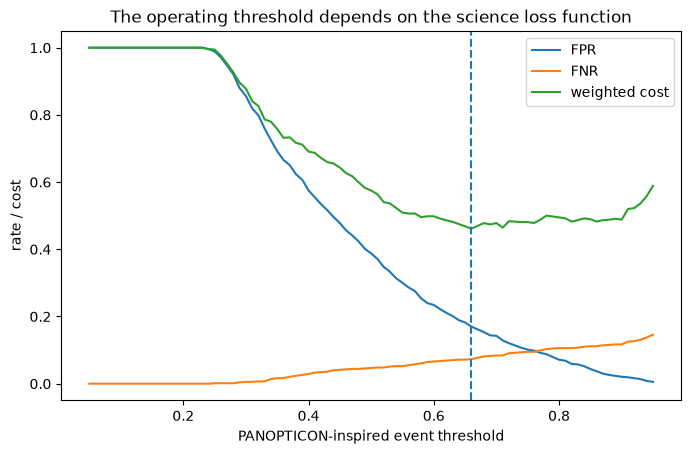

In [7]:
# STUDENT CHOICE: edit these two numbers.
false_positive_cost = 1.0
false_negative_cost = 4.0

y_true = (df.label >= 2).astype(int).to_numpy()
scores = df.panopticon_event_score.to_numpy()

thresholds = np.linspace(0.05, 0.95, 91)
rows = []
for t in thresholds:
    pred = scores >= t
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0,1]).ravel()
    fpr = fp / max(fp + tn, 1)
    tpr = tp / max(tp + fn, 1)
    cost = false_positive_cost*fpr + false_negative_cost*(1-tpr)
    rows.append((t, fpr, tpr, cost))

thr_scan = pd.DataFrame(rows, columns=['threshold','FPR','TPR','cost'])
best = thr_scan.loc[thr_scan.cost.idxmin()]
display(best.to_frame('chosen operating point').T.style.format({
    'threshold':'{:.2f}', 'FPR':'{:.1%}', 'TPR':'{:.1%}', 'cost':'{:.3f}'
}))

fig, ax = plt.subplots(figsize=(8,4.8))
ax.plot(thr_scan.threshold, thr_scan.FPR, label='FPR')
ax.plot(thr_scan.threshold, 1-thr_scan.TPR, label='FNR')
ax.plot(thr_scan.threshold, thr_scan.cost, label='weighted cost')
ax.axvline(best.threshold, ls='--')
ax.set_xlabel('PANOPTICON-inspired event threshold')
ax.set_ylabel('rate / cost')
ax.legend()
ax.set_title('The operating threshold depends on the science loss function')
plt.show()

Classroom event-level AUC: 0.958
Threshold calibrated to ~5% no-planet false alarms: 0.841
TPR = 89.0%; FPR = 5.1%


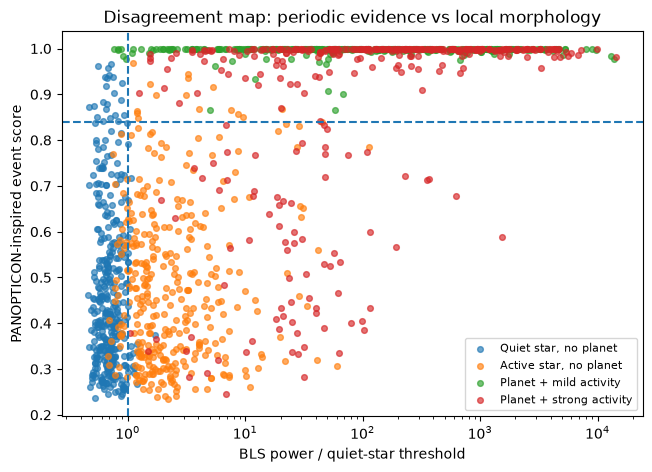

In [8]:
# Compare periodic evidence with local event morphology.
_metrics_path = MODEL_DIR / 'panopticon_metrics.json'
with open(_metrics_path) as f:
    m = json.load(f)

print(f"Classroom event-level AUC: {m['event_auc']:.3f}")
print(f"Threshold calibrated to ~5% no-planet false alarms: {m['threshold_5pct_no_planet']:.3f}")
print(f"TPR = {m['tpr']:.1%}; FPR = {m['fpr']:.1%}")

fig, ax = plt.subplots(figsize=(7.5, 5))
for c in range(4):
    s = df[df.label == c]
    ax.scatter(s.bls_power_ratio, s.panopticon_event_score,
               s=17, alpha=.65, label=CLASS_LABELS[c])
ax.axvline(1, ls='--')
ax.axhline(m['threshold_5pct_no_planet'], ls='--')
ax.set_xscale('log')
ax.set_xlabel('BLS power / quiet-star threshold')
ax.set_ylabel('PANOPTICON-inspired event score')
ax.legend(fontsize=8)
ax.set_title('Disagreement map: periodic evidence vs local morphology')
plt.show()

### Task 2C — disagreement is information

Find one scientific interpretation for each quadrant:

1. **BLS high / event score high**
2. **BLS high / event score low**
3. **BLS low / event score high**
4. **BLS low / event score low**

For quadrant 2 or 3, name the **next measurement** you would request.

> **YOUR ANSWER:**  
>

# Exercise 3A — Case study: official NASA ExoMiner++ — from event detection to multi-diagnostic vetting **[5 min]**

Now switch missions deliberately.

**ExoMiner++ is an official NASA TESS/SPOC vetting architecture**, designed to combine multiple diagnostic views. It does **not** consume the same information object as the PANOPTICON-inspired PLATO detector.

Conceptually:

\[
\text{candidate event}
+
\{\text{folded flux, difference image, centroid, trend, periodogram, spacecraft context, ...}\}
\rightarrow
P(\mathrm{planet}\mid\mathrm{diagnostics}).
\]

This is a useful lesson: **more relational views can change the scientific question from detection to explanation/vetting.**

> **Important:** ExoMiner++ is **not** applied directly to our PLATO-like simulation. The official model expects TESS/SPOC diagnostic products that are not present in the synthetic PLATO dataset. We therefore use real TESS examples to study the logic of production vetting.

### Task 3A.1
Inspect the architecture and determine which branches could veto an otherwise convincing transit-shaped signal.


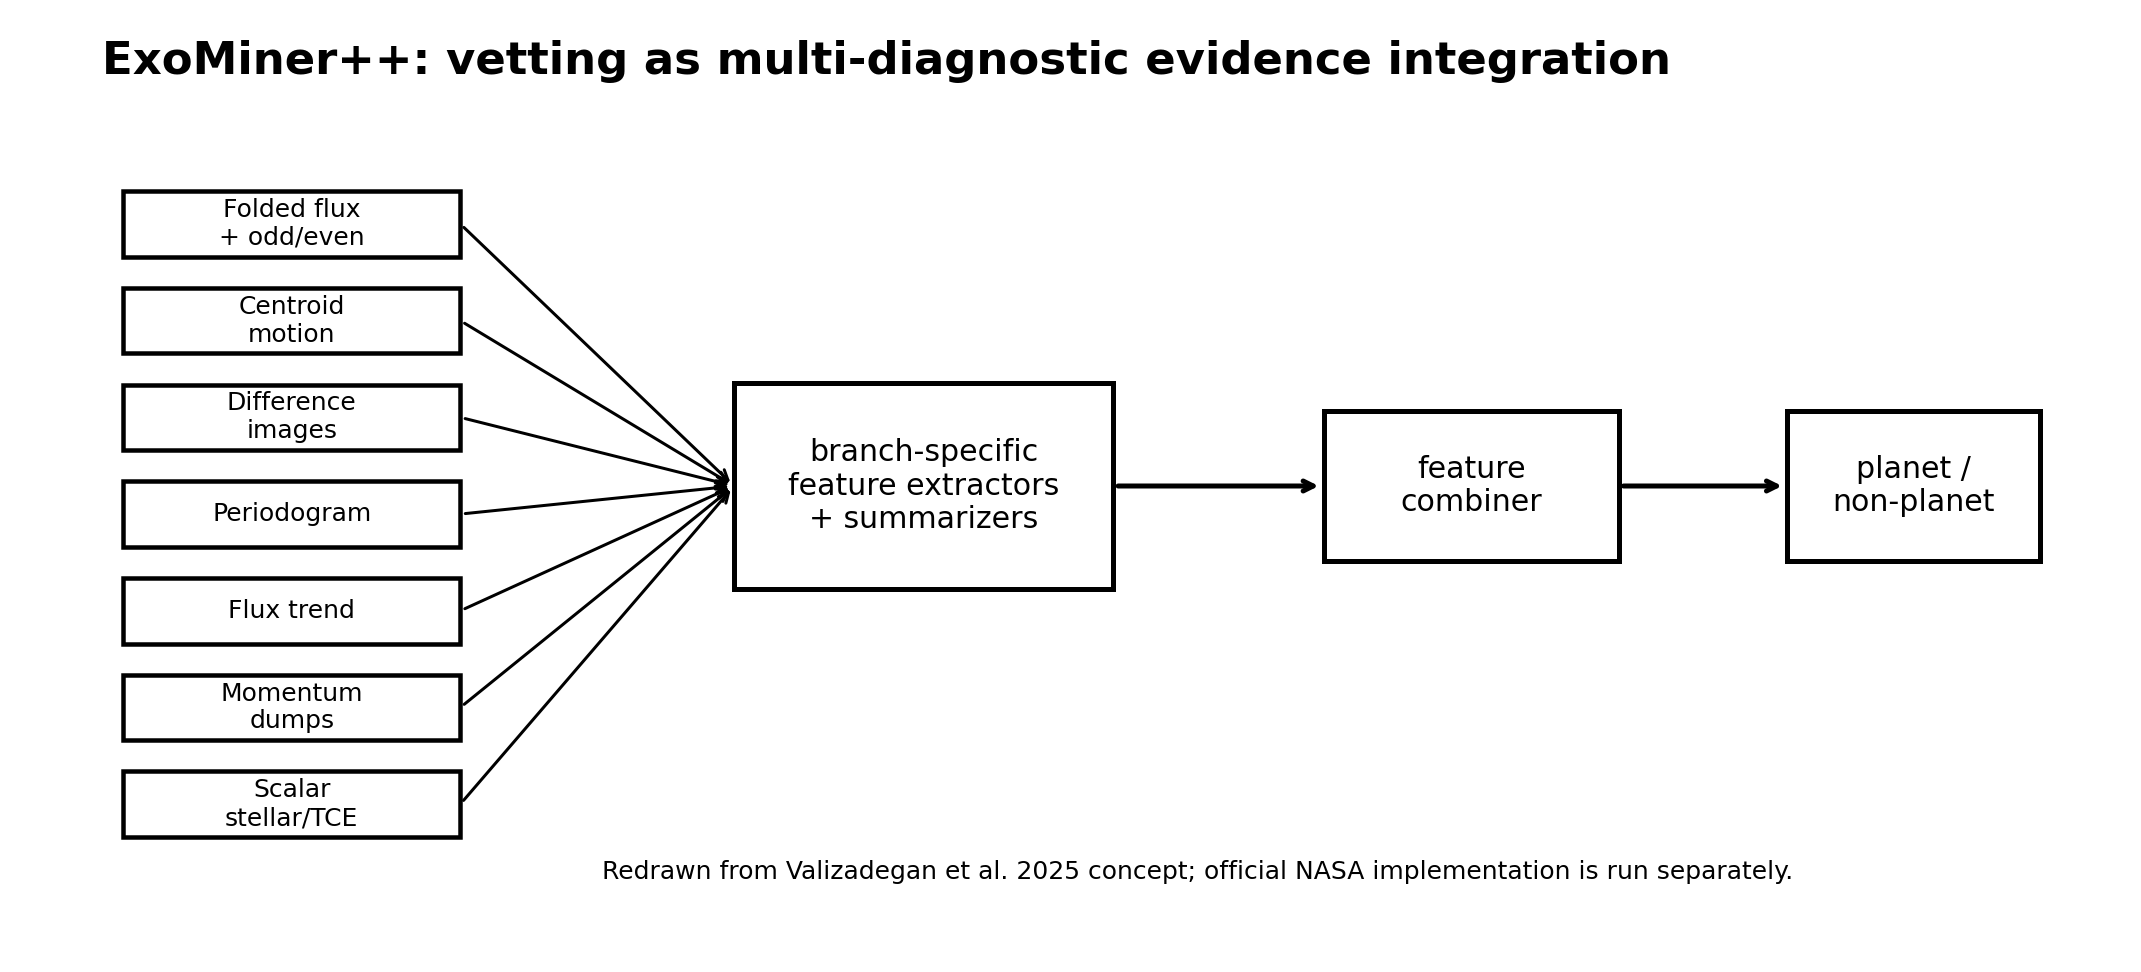

Prepared official-demo targets:
  TIC 261136679 S1  — π Mensae c, confirmed transiting super-Earth
  TIC 167526485 S6  — published EB / ellipsoidal-variation example

The official NASA ExoMiner++ pipeline is kept separate from the PLATO simulation
because it expects TESS/SPOC diagnostic products.


In [9]:
_exo_arch = ASSET_DIR / 'exominerpp_architecture.png'
if _exo_arch.exists():
    ipydisplay(Image(filename=str(_exo_arch), width=950))

print('Prepared official-demo targets:')
print('  TIC 261136679 S1  — π Mensae c, confirmed transiting super-Earth')
print('  TIC 167526485 S6  — published EB / ellipsoidal-variation example')
print()
print('The official NASA ExoMiner++ pipeline is kept separate from the PLATO simulation')
print('because it expects TESS/SPOC diagnostic products.')

In [10]:
# OFFICIAL NASA EXOMINER++ OUTPUT CHECK
# This notebook does not reimplement ExoMiner++.

hits = find_exominer_predictions(ROOT)

if not hits:
    print('No cached official ExoMiner++ prediction output is present in this package yet.')
    print('For the live school demo, the instructor can pre-run:')
    print(f'  cd "{ROOT}"')
    print('  ./exominer_official/run_exominer_official.sh')
    print()
    print('Students can still complete the diagnostic reasoning task below.')

else:
    print('Official NASA ExoMiner++ prediction file(s) found:')
    for h in hits:
        print(' ', h)

    # NASA prediction files begin with comment-style metadata lines.
    exo = pd.read_csv(hits[0], comment='#')

    # The current pipeline may write duplicate rows for the same TCE.
    # Keep one row per unique event for the classroom display.
    exo = exo.drop_duplicates(subset='uid').reset_index(drop=True)

    show_cols = [
        'uid',
        'target_id',
        'sector_run',
        'tce_period',
        'tce_duration',
        'tce_depth',
        'tce_prad',
        'matchedToiId',
        'score',
        'score_std'
    ]

    show_cols = [c for c in show_cols if c in exo.columns]

    print('\nOfficial ExoMiner++ inference results:')
    display(exo[show_cols])

    print('\nInterpretation:')
    for _, row in exo.iterrows():
        print(
            f"TIC {int(row['target_id'])}: "
            f"ExoMiner++ planet score = {row['score']:.4f}"
        )

Official NASA ExoMiner++ prediction file(s) found:
  /Users/angelicakovacevic/Downloads/europlanet-student-test_exominer/exominer_official/outputs/predictions_spoc-tces_set.csv

Official ExoMiner++ inference results:


,uid,target_id,sector_run,tce_period,tce_duration,tce_depth,tce_prad,matchedToiId,score,score_std
0,261136679-1-S1,261136679,1,6.267497,0.123994,301.807953,2.069075,144.00999450683594,0.983269,0.0
1,167526485-1-S6,167526485,6,5.011590,0.290035,10861.079102,40.703423,not_matched,0.002048,0.0



Interpretation:
TIC 261136679: ExoMiner++ planet score = 0.9833
TIC 167526485: ExoMiner++ planet score = 0.0020


### Task 3A.2 — diagnostic ablation

For each hypothetical candidate, predict whether the ExoMiner++ planet score should **rise**, **fall**, or remain **ambiguous**, and justify the decisive relation.

| Candidate | Transit shape | Difference image / centroid | Spacecraft events | Your expectation |
|---|---|---|---|---|
| A | convincing | on target | clean | ? |
| B | convincing | offset from target | clean | ? |
| C | convincing | on target | repeated momentum-dump coincidence | ? |
| D | weak | on target | clean | ? |

**Question:** Why would it be scientifically wrong to feed a PLATO light curve directly into the TESS/SPOC ExoMiner++ pipeline and call the output a fair benchmark?

> **YOUR ANSWER:**  
>


# Exercise 3B — **PLATO multi-diagnostic vetter — classroom model inspired by the ExoMiner philosophy** **[8 min]**

We now return to the **student PLATO-like simulations**.

We do **not** copy the ExoMiner++ architecture. Instead, we transfer one scientific principle:

\[
\boxed{\text{a candidate should be vetted by combining several diagnostic views, not by one detection score alone}.}
\]

The classroom vetter combines only quantities that are legitimate downstream evidence or contextual information:

- BLS periodic evidence and fitted depth;
- PANOPTICON-inspired local event morphology;
- white-noise and stellar-activity scale;
- the **relation** between the BLS candidate period and the stellar rotation period;
- basic stellar context \((T_{\rm eff}, \log g)\).

The following are **not inputs**: `label`, `planet_present`, injected planet period/radius/depth, or the true transit mask. They are simulation truth and are used only as targets/evaluation labels.

To avoid giving an object a score from a model that trained on that same object, we use **5-fold out-of-fold (OOF) predictions**.

> **Provenance:** this is a small scikit-learn logistic-fusion **classroom model** built for this practical. It is **not ExoMiner++**, not NASA code, and not a PLATO mission-performance forecast.

### Scientific question

Does adding independent or partly independent diagnostics improve vetting over BLS alone?


Out-of-fold classroom ablation:


,representation,OOF ROC AUC,TPR @ 0.5,FPR @ 0.5,accuracy @ 0.5,ΔAUC from previous
0,BLS power only,0.972,89.3%,6.2%,91.6%,—
1,BLS power + fitted depth,0.991,96.6%,3.6%,96.5%,+0.019
2,BLS + depth + local morphology,0.995,96.1%,2.3%,96.9%,+0.005
3,PLATO multi-diagnostic context,0.996,96.6%,2.3%,97.1%,+0.001


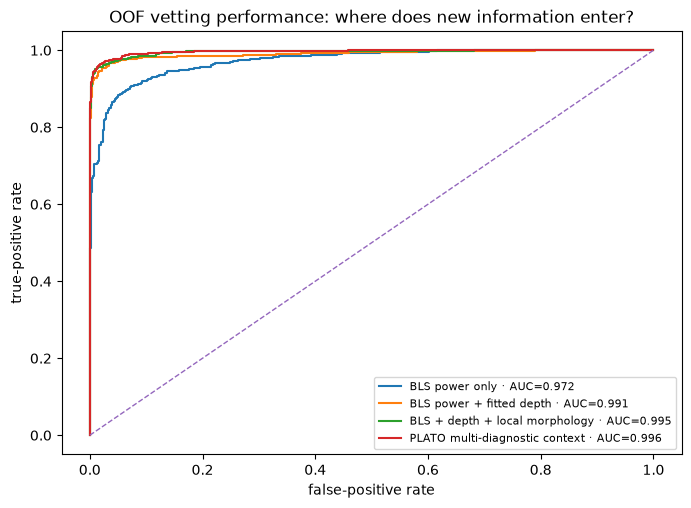

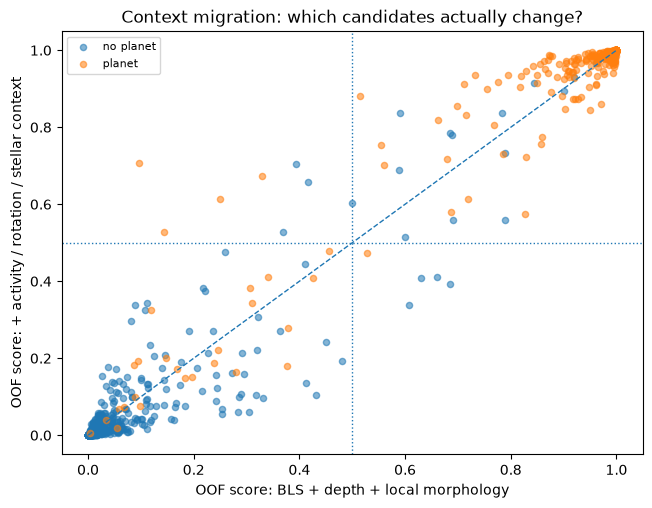

Direction/strength of fitted classroom fusion weights (conditional, not causal):


,diagnostic,standardized coefficient
0,log_bls_power_ratio,+2.274
1,log_bls_depth_ppm,+2.016
2,panopticon_event_score,+1.754
5,period_rotation_log_sep,-1.301
7,logg,-0.803
3,log_sigma_ppm,+0.400
6,teff,-0.071
4,log_act_rms,+0.026



✓ PLATO classroom vetter ready.
  Mission-board scores are 5-fold out-of-fold predictions.
  They are classroom ranking scores, not calibrated PLATO mission probabilities.

Scientific caution: predictive coefficients describe this simulated population and this representation. They are not causal astrophysical laws.


In [11]:
# === PLATO MULTI-DIAGNOSTIC VETTER ===
# Classroom model inspired by the ExoMiner philosophy — NOT ExoMiner++.
#
# Scientific purpose:
# test where predictive information enters as progressively richer
# diagnostic views are admitted.

from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

vetter_df = df.copy()

# ---------------------------------------------------------------------
# 1. Construct permitted evidence/context variables
# ---------------------------------------------------------------------
# IMPORTANT:
# Simulation-truth quantities such as planet_present, label,
# injected planet period/radius/depth, and the true transit mask
# are NOT used as model inputs.

_EPS = 1e-8

vetter_df['log_bls_power_ratio'] = np.log10(
    np.clip(vetter_df['bls_power_ratio'].astype(float), _EPS, None)
)

vetter_df['log_bls_depth_ppm'] = np.log10(
    np.clip(np.abs(vetter_df['bls_depth_ppm'].astype(float)), 1e-3, None)
)

vetter_df['log_sigma_ppm'] = np.log10(
    np.clip(vetter_df['sigma_ppm'].astype(float), 1e-3, None)
)

vetter_df['log_act_rms'] = np.log10(
    np.clip(vetter_df['act_rms'].astype(float), 1e-3, None)
)

# Relational diagnostic:
# distance in log-period space between the BLS candidate period
# and the stellar rotation period.
vetter_df['period_rotation_log_sep'] = np.abs(
    np.log10(
        np.clip(vetter_df['bls_period'].astype(float), 1e-6, None)
        /
        np.clip(vetter_df['rotation_period_days'].astype(float), 1e-6, None)
    )
)

# ---------------------------------------------------------------------
# 2. Progressive representations
# ---------------------------------------------------------------------
# This is deliberately an ablation ladder.
# We want to know WHERE the additional predictive information enters.

feature_sets = {
    'BLS power only': [
        'log_bls_power_ratio'
    ],

    'BLS power + fitted depth': [
        'log_bls_power_ratio',
        'log_bls_depth_ppm'
    ],

    'BLS + depth + local morphology': [
        'log_bls_power_ratio',
        'log_bls_depth_ppm',
        'panopticon_event_score'
    ],

    'PLATO multi-diagnostic context': [
        'log_bls_power_ratio',
        'log_bls_depth_ppm',
        'panopticon_event_score',
        'log_sigma_ppm',
        'log_act_rms',
        'period_rotation_log_sep',
        'teff',
        'logg',
    ],
}

# Simulation truth is used ONLY as supervised target/evaluation truth.
y_vetter = vetter_df['planet_present'].astype(int).to_numpy()


def make_vetter():
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scale', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=2000,
            class_weight='balanced',
            random_state=7
        )),
    ])


# Every object must be evaluated by a model that did not train on it.
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=7
)

vetter_scores = {}
vetter_rows = []

for name, feats in feature_sets.items():

    oof_score = cross_val_predict(
        make_vetter(),
        vetter_df[feats],
        y_vetter,
        cv=cv,
        method='predict_proba'
    )[:, 1]

    vetter_scores[name] = oof_score

    pred = oof_score >= 0.5
    tn, fp, fn, tp = confusion_matrix(
        y_vetter, pred, labels=[0, 1]
    ).ravel()

    vetter_rows.append({
        'representation': name,
        'OOF ROC AUC': roc_auc_score(y_vetter, oof_score),
        'TPR @ 0.5': tp / max(tp + fn, 1),
        'FPR @ 0.5': fp / max(fp + tn, 1),
        'accuracy @ 0.5': (tp + tn) / len(y_vetter),
    })


vetter_summary = pd.DataFrame(vetter_rows)

# Incremental gain relative to the immediately preceding representation.
vetter_summary['ΔAUC from previous'] = (
    vetter_summary['OOF ROC AUC'].diff()
)

print('Out-of-fold classroom ablation:')
display(
    vetter_summary.style.format({
        'OOF ROC AUC': '{:.3f}',
        'ΔAUC from previous':
            lambda x: '—' if pd.isna(x) else f'{x:+.3f}',
        'TPR @ 0.5': '{:.1%}',
        'FPR @ 0.5': '{:.1%}',
        'accuracy @ 0.5': '{:.1%}',
    })
)

# ---------------------------------------------------------------------
# 3. ROC comparison
# ---------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5.5))

for name, score in vetter_scores.items():
    fpr, tpr, _ = roc_curve(y_vetter, score)

    ax.plot(
        fpr,
        tpr,
        label=f"{name} · AUC={roc_auc_score(y_vetter, score):.3f}"
    )

ax.plot([0, 1], [0, 1], ls='--', lw=1)

ax.set_xlabel('false-positive rate')
ax.set_ylabel('true-positive rate')

ax.set_title(
    'OOF vetting performance: where does new information enter?'
)

ax.legend(fontsize=8)

plt.show()


# ---------------------------------------------------------------------
# 4. Context-migration plot
# ---------------------------------------------------------------------
# Compare the strongest signal-level representation
# against the same representation after adding activity/rotation/
# stellar context.
#
# Points far from the diagonal are scientifically interesting:
# context has materially changed the decision.

pre_context_name = 'BLS + depth + local morphology'
full_context_name = 'PLATO multi-diagnostic context'

fig, ax = plt.subplots(figsize=(7.5, 5.5))

for truth, label in [(0, 'no planet'), (1, 'planet')]:
    q = (y_vetter == truth)

    ax.scatter(
        vetter_scores[pre_context_name][q],
        vetter_scores[full_context_name][q],
        s=20,
        alpha=.55,
        label=label
    )

ax.plot([0, 1], [0, 1], ls='--', lw=1)
ax.axhline(0.5, ls=':', lw=1)
ax.axvline(0.5, ls=':', lw=1)

ax.set_xlabel(
    'OOF score: BLS + depth + local morphology'
)

ax.set_ylabel(
    'OOF score: + activity / rotation / stellar context'
)

ax.set_title(
    'Context migration: which candidates actually change?'
)

ax.legend(fontsize=8)

plt.show()


# ---------------------------------------------------------------------
# 5. Fit one full-data model for INTERPRETATION ONLY
# ---------------------------------------------------------------------
# Performance above is out-of-fold.
# This fit is used only to inspect the direction of standardized
# conditional coefficients and for later classroom demonstration.

final_features = feature_sets['PLATO multi-diagnostic context']

plato_vetter_model = make_vetter()

plato_vetter_model.fit(
    vetter_df[final_features],
    y_vetter
)

coef = plato_vetter_model.named_steps['clf'].coef_[0]

coef_table = pd.DataFrame({
    'diagnostic': final_features,
    'standardized coefficient': coef
}).sort_values(
    'standardized coefficient',
    key=np.abs,
    ascending=False
)

print(
    'Direction/strength of fitted classroom fusion weights '
    '(conditional, not causal):'
)

display(
    coef_table.style.format({
        'standardized coefficient': '{:+.3f}'
    })
)


# ---------------------------------------------------------------------
# 6. Save final OOF score for the mission board
# ---------------------------------------------------------------------
# Each object receives a score from a model that did not train on it.

plato_vetter_output = pd.DataFrame({
    'file_id': vetter_df['file_id'].astype(int),
    'plato_vetter_score':
        vetter_scores['PLATO multi-diagnostic context']
})

print()
print('✓ PLATO classroom vetter ready.')
print(
    '  Mission-board scores are 5-fold out-of-fold predictions.'
)
print(
    '  They are classroom ranking scores, not calibrated '
    'PLATO mission probabilities.'
)
print()
print(
    'Scientific caution: predictive coefficients describe this '
    'simulated population and this representation. They are not '
    'causal astrophysical laws.'
)

In [12]:
# === WHICH INDIVIDUAL DECISIONS CHANGED? ===

pre_score = vetter_scores[
    'BLS + depth + local morphology'
]

context_score = vetter_scores[
    'PLATO multi-diagnostic context'
]

# Crossing the classroom decision threshold
rescued = (pre_score < 0.5) & (context_score >= 0.5)
vetoed  = (pre_score >= 0.5) & (context_score < 0.5)

# Magnitude of score movement
delta_context = context_score - pre_score

print('Effect of adding activity / rotation / stellar context:')
print(f'  rescued across 0.5 threshold : {rescued.sum()}')
print(f'  vetoed across 0.5 threshold  : {vetoed.sum()}')
print(
    f'  median |score change|        : '
    f'{np.median(np.abs(delta_context)):.3f}'
)
print(
    f'  maximum |score change|       : '
    f'{np.max(np.abs(delta_context)):.3f}'
)

migration_table = pd.DataFrame({
    'file_id': vetter_df['file_id'].astype(int),
    'truth_for_evaluation': y_vetter,
    'pre_context_score': pre_score,
    'context_score': context_score,
    'Δscore': delta_context,
    'decision_changed': rescued | vetoed,
})

migration_table = migration_table.sort_values(
    'Δscore',
    key=np.abs,
    ascending=False
)

print('\nCandidates most affected by contextual information:')

display(
    migration_table.head(12).style.format({
        'pre_context_score': '{:.3f}',
        'context_score': '{:.3f}',
        'Δscore': '{:+.3f}',
    })
)

Effect of adding activity / rotation / stellar context:
  rescued across 0.5 threshold : 8
  vetoed across 0.5 threshold  : 5
  median |score change|        : 0.002
  maximum |score change|       : 0.609

Candidates most affected by contextual information:


,file_id,truth_for_evaluation,pre_context_score,context_score,Δscore,decision_changed
110,1153,1,0.097,0.706,+0.609,True
1434,1430,1,0.143,0.527,+0.384,True
724,1207,1,0.515,0.881,+0.366,False
164,1226,1,0.249,0.612,+0.363,True
748,1405,1,0.329,0.673,+0.343,True
955,484,0,0.431,0.105,-0.326,False
1185,218,0,0.393,0.705,+0.312,True
493,664,0,0.686,0.394,-0.292,True
694,742,0,0.481,0.193,-0.287,False
696,426,0,0.412,0.135,-0.277,False


### Population performance versus individual decisions

The final contextual variables produce only a small improvement in the
population-level ROC AUC:

\[
\Delta \mathrm{AUC} \simeq 0.001.
\]

This does **not** imply that the contextual information is irrelevant.

The migration analysis asks a different question:

> For which individual candidates does admitting additional physical context
> materially change the inference?

A diagnostic can therefore have little effect on the **global ranking metric**
while still being decisive for a small number of ambiguous objects.

This distinction is important in scientific triage:

\[
\boxed{
\text{population-level performance}
\neq
\text{object-level scientific value}
}
\]

Candidates far from the diagonal are particularly interesting because their
classification depends strongly on which information is admitted to the model.

For these objects, the correct scientific response is not simply to trust the
new score. Instead ask:

1. Which diagnostic caused the movement?
2. Is that relation physically plausible?
3. Could it arise from the construction of the simulated population?
4. What independent observation would resolve the disagreement?

### Interpreting the result — prediction is not physical explanation

The important result is **not simply that the final AUC is high**.

The ablation asks where the predictive information enters:

\[
\mathrm{BLS\ power}
\rightarrow
+\mathrm{depth}
\rightarrow
+\mathrm{local\ morphology}
\rightarrow
+\mathrm{activity/rotation/stellar\ context}.
\]

If most of the performance gain occurs before the final step, then the additional
context is largely **redundant for this particular simulated population**.

This illustrates an important information-theory principle:

\[
I(Y;X_1,X_2)
=
I(Y;X_1)
+
I(Y;X_2\mid X_1).
\]

A new diagnostic is scientifically valuable only to the extent that it contributes
**conditional information** not already encoded by the previous representation.

#### Important caution about the coefficient table

The displayed coefficients are **standardized conditional coefficients of a
logistic classroom model**. They are:

- not causal effects;
- not universal astrophysical relations;
- not measures of intrinsic physical importance;
- and not PLATO mission-performance predictions.

Correlated predictors can change one another's fitted coefficients.

In particular, inspect `period_rotation_log_sep` carefully. It is defined as

\[
d_{P,\mathrm{rot}}
=
\left|
\log_{10}
\frac{P_{\mathrm{BLS}}}{P_{\mathrm{rot}}}
\right|.
\]

If its fitted coefficient is **negative**, then in this classroom realization the
model gives greater planet support when the BLS period lies closer to the stellar
rotation period.

That should **not** immediately be interpreted as a physical rule.

Instead ask:

> Is the model discovering astrophysics, or faithfully learning how this simulated
> population was constructed?

This is a central AI co-intelligence question:

\[
\boxed{\text{predictive association} \neq \text{physical explanation}}
\]

A scientifically responsible user therefore inspects both **performance** and
whether the learned relations make physical sense.

### Task 3B.2 — interrogate the vetter, not only its AUC

Use the ablation table, ROC curves, coefficient table, and context-migration plot.

1. **Where does most of the predictive gain enter?**  
   Compare

   \[
   \mathrm{BLS\ power}
   \rightarrow
   +\mathrm{depth}
   \rightarrow
   +\mathrm{local\ morphology}
   \rightarrow
   +\mathrm{context}.
   \]

   Which additional representation contributes the largest increase in OOF AUC?

2. **Does more information always help substantially?**  
   Compare the gain from local morphology with the gain from adding activity,
   rotation and stellar context.

3. `period_rotation_log_sep` is

   \[
   \left|
   \log_{10}
   (P_{\rm BLS}/P_{\rm rot})
   \right|.
   \]

   Why is this a **relational feature** rather than a single measurement?
   Does the sign of its fitted coefficient agree with your physical expectation?

4. If the coefficient has an unexpected sign, give at least two possible
   explanations:
   - genuine astrophysics;
   - correlations among predictors;
   - properties of the simulated population;
   - selection effects;
   - model misspecification.

5. In the **context-migration plot**, identify objects far from the diagonal.
   Why are these objects scientifically more interesting than candidates whose
   scores barely move?

6. Why are the quoted performance scores **out-of-fold**, while the coefficient
   table comes from a final fit to the full dataset?

7. Which missing observation would provide the largest genuinely new information
   for a difficult candidate: centroid/difference imaging, colour dependence,
   RV, another transit epoch, activity indicators, or something else?

### AI co-intelligence question

A model achieves excellent classification performance but one of its strongest
learned relations conflicts with your physical intuition.

**What should the scientist do next rather than simply trusting or rejecting the model?**

> **YOUR ANSWER:**  
>


# Exercise 4 — Neural Processes: **locality, attention, and latent uncertainty** **[20 min]**

A tiny mean-pooled CNP is not an appropriate raw transit reconstructor because every target receives the same global context summary:

\[
r_i=h_\theta(x_i,y_i), \qquad
r=\frac{1}{N_C}\sum_i r_i,
\qquad
p(y_*|x_*,C)=g_\phi(x_*,r).
\]

For a narrow transit, only a small fraction of the context may contain ingress, bottom, or egress. Global pooling can therefore dilute precisely the relation we care about.

We now compare **two stronger Neural Process representations**:

\[
\boxed{\mathrm{ConvCNP}:\; C\rightarrow\text{local function representation}\rightarrow\text{CNN}\rightarrow y_*}
\]

and

\[
\boxed{\mathrm{AttnLNP}:\; C\rightarrow\text{target-specific attention }r_*\; +\; \text{latent }z\rightarrow y_*}.
\]

The full AttnLNP classroom model below contains both paths:

- **deterministic attentive path:** each target \(x_*\) asks which context points are relevant;
- **latent path:** \(q(z\mid C)\) represents a global distribution over functions consistent with the context;
- **training posterior:** \(q(z\mid C,T)\) uses target information only during training;
- **variational objective:** reconstruction likelihood plus a KL term aligning posterior and context prior.

> **Provenance:** both implementations are compact teaching models written for this practical. They reproduce the relevant architectural ideas, but they are **not** the authors' released code. The architecture schematics below are original classroom diagrams based on the Neural Process Family reproducibility pages supplied for this practical.


### Architecture map — ConvCNP versus AttnLNP

The diagrams below make the two information flows explicit.

**ConvCNP:** irregular context is converted into a local function-space representation, processed with convolutions, and queried back at target locations.

**AttnLNP:** the deterministic branch computes a target-dependent attended representation, while the latent branch defines a stochastic global state. During training, the posterior sees context + target; during prediction, only the context prior is available.


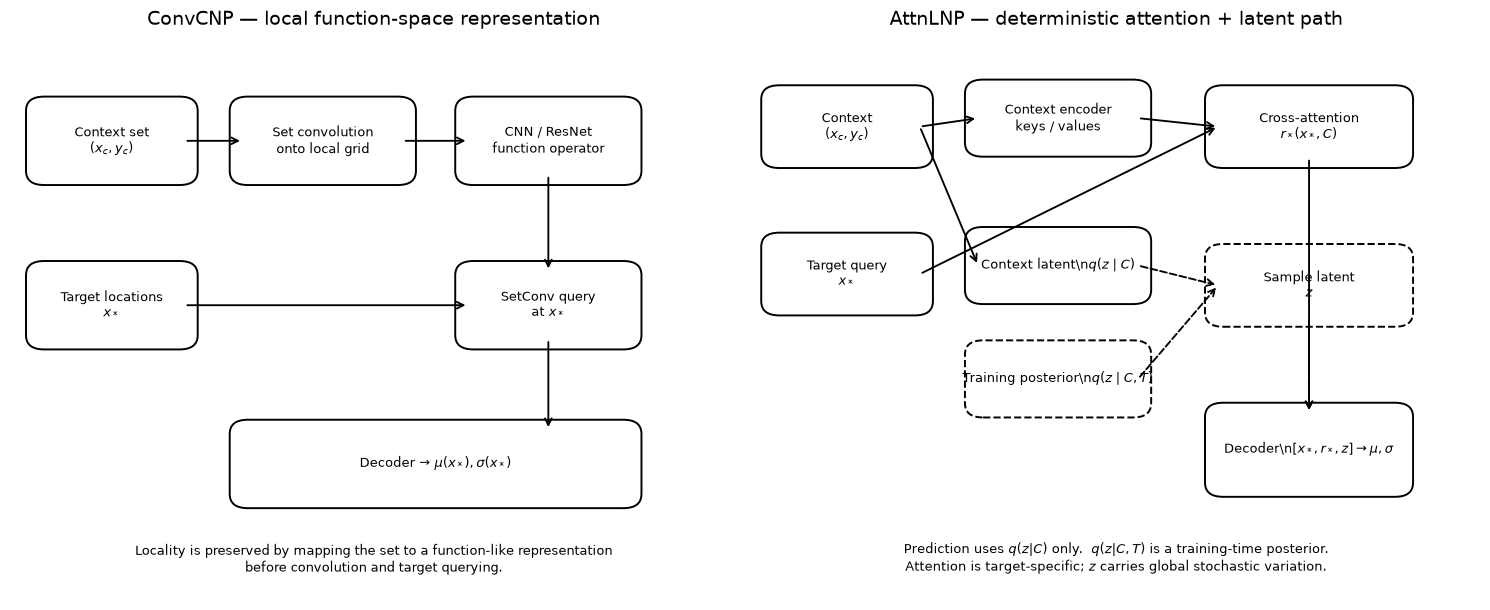

In [13]:
# === ORIGINAL CLASSROOM ARCHITECTURE SCHEMATICS ===
# Conceptually based on:
# https://yanndubs.github.io/Neural-Process-Family/reproducibility/ConvCNP.html
# https://yanndubs.github.io/Neural-Process-Family/reproducibility/AttnLNP.html

from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

def _abox(ax, x, y, w, h, text, fs=9.5, ls='-'):
    p = FancyBboxPatch(
        (x, y), w, h,
        boxstyle='round,pad=0.018,rounding_size=0.025',
        fill=False, linewidth=1.4, linestyle=ls
    )
    ax.add_patch(p)
    ax.text(x+w/2, y+h/2, text, ha='center', va='center', fontsize=fs)

def _aarrow(ax, x1, y1, x2, y2, ls='-'):
    ax.add_patch(FancyArrowPatch(
        (x1, y1), (x2, y2), arrowstyle='->', mutation_scale=12,
        linewidth=1.35, linestyle=ls
    ))

fig, axes = plt.subplots(1, 2, figsize=(15, 6.2))

# --- ConvCNP ---
ax = axes[0]
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
ax.set_title('ConvCNP — local function-space representation', fontsize=14)

_abox(ax, .04, .75, .20, .12, 'Context set\n$(x_c,y_c)$')
_abox(ax, .32, .75, .22, .12, 'Set convolution\nonto local grid')
_abox(ax, .63, .75, .22, .12, 'CNN / ResNet\nfunction operator')
_abox(ax, .04, .46, .20, .12, 'Target locations\n$x_*$')
_abox(ax, .63, .46, .22, .12, 'SetConv query\nat $x_*$')
_abox(ax, .32, .18, .53, .12, r'Decoder → $\mu(x_*),\sigma(x_*)$')

_aarrow(ax,.24,.81,.32,.81)
_aarrow(ax,.54,.81,.63,.81)
_aarrow(ax,.74,.75,.74,.58)
_aarrow(ax,.24,.52,.63,.52)
_aarrow(ax,.74,.46,.74,.30)
ax.text(.50,.05,
        'Locality is preserved by mapping the set to a function-like representation\nbefore convolution and target querying.',
        ha='center', fontsize=9.5)

# --- AttnLNP ---
ax = axes[1]
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis('off')
ax.set_title('AttnLNP — deterministic attention + latent path', fontsize=14)

_abox(ax,.03,.78,.20,.11,'Context\n$(x_c,y_c)$')
_abox(ax,.31,.80,.22,.10,'Context encoder\nkeys / values')
_abox(ax,.03,.52,.20,.11,'Target query\n$x_*$')
_abox(ax,.64,.78,.25,.11,'Cross-attention\n$r_*(x_*,C)$')

_abox(ax,.31,.54,.22,.10,r'Context latent\n$q(z\mid C)$')
_abox(ax,.31,.34,.22,.10,r'Training posterior\n$q(z\mid C,T)$', ls='--')
_abox(ax,.64,.50,.25,.11,'Sample latent\n$z$', ls='--')
_abox(ax,.64,.20,.25,.13,r'Decoder\n$[x_*,r_*,z]\to\mu,\sigma$')

_aarrow(ax,.23,.835,.31,.85)
_aarrow(ax,.23,.835,.31,.59)
_aarrow(ax,.23,.575,.64,.835)
_aarrow(ax,.53,.85,.64,.835)
_aarrow(ax,.53,.59,.64,.555, ls='--')
_aarrow(ax,.53,.39,.64,.555, ls='--')
_aarrow(ax,.765,.78,.765,.33)
_aarrow(ax,.765,.50,.765,.33, ls='--')
ax.text(.50,.05,
        'Prediction uses $q(z|C)$ only.  $q(z|C,T)$ is a training-time posterior.\nAttention is target-specific; $z$ carries global stochastic variation.',
        ha='center', fontsize=9.5)

plt.tight_layout()
plt.show()


### Task 4A — read the architectures before running them

1. In **ConvCNP**, which operation makes the representation local rather than globally pooled?  
2. In **AttnLNP**, where does the representation become target-specific?  
3. Why is \(q(z\mid C,T)\) allowed during training but unavailable for a genuinely unseen target at inference time?  
4. What is the difference between **attention uncertainty** and **latent uncertainty**?

> **YOUR ANSWER:**  
>


✓ Tiny ConvCNP-style model trained in 99.04 s
Train/test tasks: 80 / 20
Learned set-convolution length scale: 0.007954812608659267


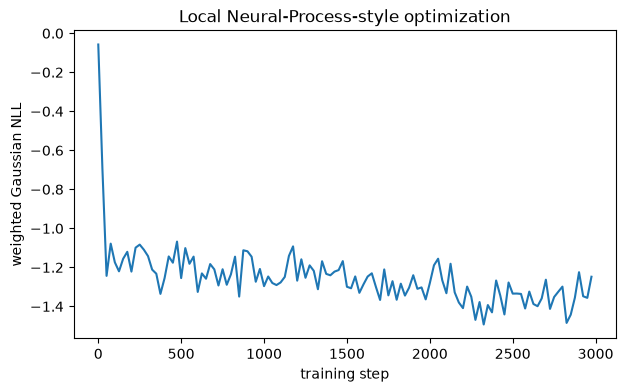

In [14]:
class TinyConvCNP(nn.Module):
    # Compact ConvCNP-style classroom model; not author code.
    def __init__(self, grid, ell=0.025, hidden=48):
        super().__init__()
        self.register_buffer('grid', grid)
        self.log_ell = nn.Parameter(torch.tensor(math.log(ell), dtype=torch.float32))
        self.net = nn.Sequential(
            nn.Conv1d(2, hidden, 5, padding=2), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 5, padding=4, dilation=2), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 5, padding=8, dilation=4), nn.ReLU(),
            nn.Conv1d(hidden, hidden, 5, padding=16, dilation=8), nn.ReLU(),
            nn.Conv1d(hidden, 2, 1)
        )

    def forward(self, x_context, y_context):
        # x_context, y_context: [B, Nc], x normalized to [-1,1]
        ell = torch.exp(self.log_ell).clamp(0.008, 0.08)

        # Set convolution: irregular context -> local representation on a grid.
        d = (self.grid[None, :, None] - x_context[:, None, :]) / ell
        w = torch.exp(-0.5 * d**2)

        density = w.sum(dim=-1)
        signal = (w * y_context[:, None, :]).sum(dim=-1) / (density + 1e-6)

        # The density channel exposes where the context supports inference.
        representation = torch.stack([signal, torch.log1p(density)], dim=1)

        out = self.net(representation)
        mu = out[:, 0, :]
        sigma = 0.04 + F.softplus(out[:, 1, :])
        return mu, sigma, density


_np = np.load(DATA_DIR / 'panopticon_eval_windows.npz')

_t = torch.tensor(_np['time'], dtype=torch.float32)
_y = torch.tensor(np.clip(_np['flux'], -20, 10), dtype=torch.float32)
_labels = _np['label'].astype(int)

_tmin = _t.min(dim=1, keepdim=True).values
_tmax = _t.max(dim=1, keepdim=True).values
_tn = 2 * (_t - _tmin) / (_tmax - _tmin) - 1

Y_SCALE = 5.0
_yn = _y / Y_SCALE

# Stratified 80/20 split: 20 train + 5 test from each of C0..C3.
train_ids, test_ids = [], []
for c in np.unique(_labels):
    ids = np.where(_labels == c)[0]
    train_ids.extend(ids[:20])
    test_ids.extend(ids[20:])
train_ids = np.array(train_ids)
test_ids = np.array(test_ids)

grid = torch.linspace(-1, 1, _tn.shape[1])
convcnp = TinyConvCNP(grid)

optimizer = torch.optim.Adam(convcnp.parameters(), lr=2e-3)
rng_np = np.random.default_rng(7)
torch.manual_seed(7)

def _training_context(idx, n_context=96):
    # For this supervised interpolation exercise, simulated planet tasks
    # deliberately include a few labelled transit samples in the context.
    # The truth mask is used only to build training examples; it is NOT
    # passed to the model as an input feature.
    mask = _np['mask'][idx].astype(bool)
    inside = np.where(mask)[0]
    outside = np.where(~mask)[0]

    chosen = []
    if _labels[idx] >= 2 and len(inside):
        n_in = min(8, len(inside))
        chosen.extend(rng_np.choice(inside, size=n_in, replace=False).tolist())

    remaining = n_context - len(chosen)
    chosen.extend(rng_np.choice(outside, size=remaining, replace=False).tolist())
    return np.array(sorted(chosen))

history = []
start = _time.time()

for step in range(3000):
    batch_ids = rng_np.choice(train_ids, size=12, replace=True)

    xc, yc, yt = [], [], []
    for idx in batch_ids:
        ci = _training_context(idx)
        xc.append(_tn[idx, ci])
        yc.append(_yn[idx, ci])
        yt.append(_yn[idx])

    xc = torch.stack(xc)
    yc = torch.stack(yc)
    yt = torch.stack(yt)

    mu, sigma, density = convcnp(xc, yc)

    # Simulations provide a truth mask, so rare transit samples are up-weighted.
    # The mask is NOT an inference input.
    weight = torch.ones_like(yt)
    for b, idx in enumerate(batch_ids):
        m = torch.tensor(_np['mask'][idx].astype(bool))
        weight[b, m] = 8.0

    nll = weight * (0.5 * ((yt - mu) / sigma)**2 + torch.log(sigma))
    loss = nll.sum() / weight.sum()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % 25 == 0:
        history.append((step, float(loss.detach())))

print(f'✓ Tiny ConvCNP-style model trained in {_time.time()-start:.2f} s')
print('Train/test tasks:', len(train_ids), '/', len(test_ids))
print('Learned set-convolution length scale:',
      float(torch.exp(convcnp.log_ell).detach()))

hist = pd.DataFrame(history, columns=['step', 'weighted_NLL'])
fig, ax = plt.subplots(figsize=(7,4))
ax.plot(hist.step, hist.weighted_NLL)
ax.set_xlabel('training step')
ax.set_ylabel('weighted Gaussian NLL')
ax.set_title('Local Neural-Process-style optimization')
plt.show()


### Task 4B — can a local NP representation preserve the transit?

Choose a **held-out planet light curve** and make two context sets:

1. **event-aware context:** sparse observations including a few transit samples;
2. **transit-blind context:** observations deliberately exclude the transit **and a margin around it**.

This is the key information experiment.

### Before running

Predict what should happen:

- Should the event-aware context permit recovery of the transit morphology?
- Should the transit-blind context determine a unique object-specific transit?

> **YOUR PREDICTION:**  
>


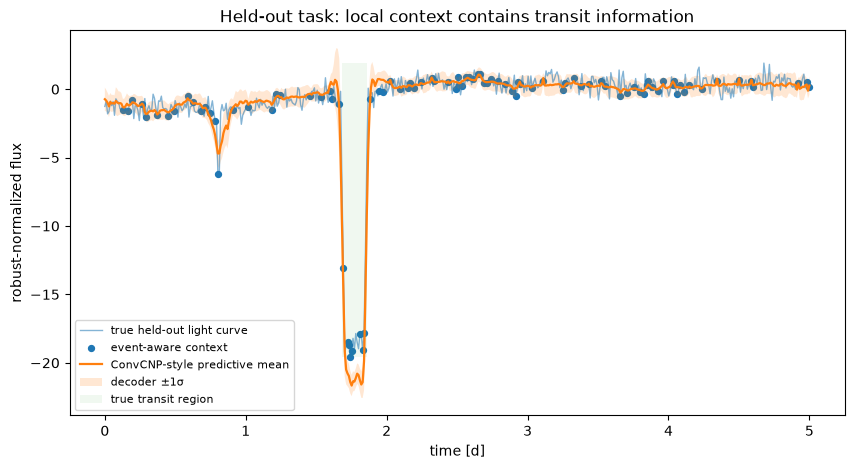

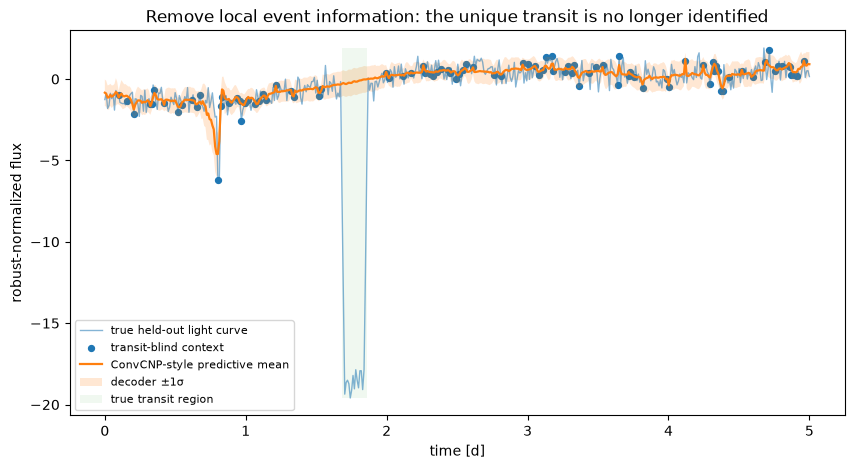

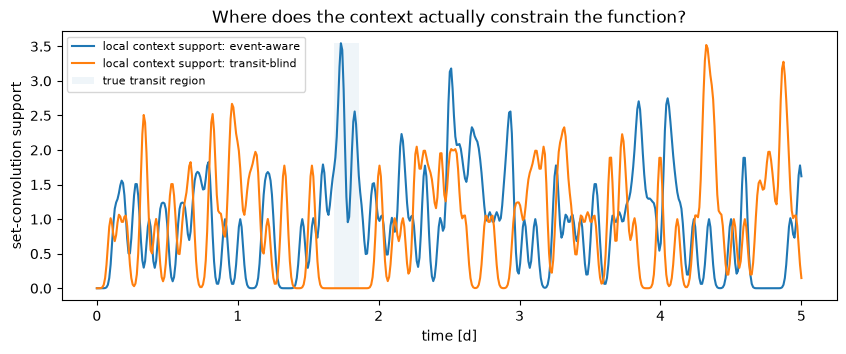

Transit-region RMSE — event-aware context : 2.597923755645752
Transit-region RMSE — transit-blind context: 17.000289916992188
Mean local support in transit — event-aware: 2.173288106918335
Mean local support in transit — blind      : 3.6421239288375595e-12


In [15]:
planet_test = np.array([i for i in test_ids if _labels[i] >= 2])
q = int(planet_test[0])

truth_mask = _np['mask'][q].astype(bool)
inside = np.where(truth_mask)[0]
outside = np.where(~truth_mask)[0]

rng_demo = np.random.default_rng(19)
n_context = 96

# Event-aware context: include a few transit points.
n_in = min(8, len(inside))
event_ctx = np.concatenate([
    rng_demo.choice(inside, size=n_in, replace=False),
    rng_demo.choice(outside, size=n_context-n_in, replace=False)
])
event_ctx = np.sort(event_ctx)

# Transit-blind context: remove event plus a margin.
all_idx = np.arange(len(truth_mask))
lo = max(0, inside.min() - 12)
hi = min(len(truth_mask)-1, inside.max() + 12)
far_from_event = np.where((all_idx < lo) | (all_idx > hi))[0]
blind_ctx = np.sort(rng_demo.choice(far_from_event, size=n_context, replace=False))

def _convcnp_predict(context_idx):
    with torch.no_grad():
        mu, sig, density = convcnp(
            _tn[q, context_idx][None, :],
            _yn[q, context_idx][None, :]
        )
    return (
        mu[0].numpy() * Y_SCALE,
        sig[0].numpy() * Y_SCALE,
        density[0].numpy()
    )

mu_event, sig_event, support_event = _convcnp_predict(event_ctx)
mu_blind, sig_blind, support_blind = _convcnp_predict(blind_ctx)

t_plot = _np['time'][q]
y_plot = _np['flux'][q]

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(t_plot, y_plot, lw=1, alpha=.55, label='true held-out light curve')
ax.scatter(t_plot[event_ctx], y_plot[event_ctx], s=18, label='event-aware context')
ax.plot(t_plot, mu_event, lw=1.6, label='ConvCNP-style predictive mean')
ax.fill_between(t_plot, mu_event-sig_event, mu_event+sig_event,
                alpha=.18, label='decoder ±1σ')
ax.fill_between(t_plot, y_plot.min(), y_plot.max(),
                where=truth_mask, alpha=.07, label='true transit region')
ax.set_xlabel('time [d]')
ax.set_ylabel('robust-normalized flux')
ax.set_title('Held-out task: local context contains transit information')
ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(10,5))
ax.plot(t_plot, y_plot, lw=1, alpha=.55, label='true held-out light curve')
ax.scatter(t_plot[blind_ctx], y_plot[blind_ctx], s=18, label='transit-blind context')
ax.plot(t_plot, mu_blind, lw=1.6, label='ConvCNP-style predictive mean')
ax.fill_between(t_plot, mu_blind-sig_blind, mu_blind+sig_blind,
                alpha=.18, label='decoder ±1σ')
ax.fill_between(t_plot, y_plot.min(), y_plot.max(),
                where=truth_mask, alpha=.07, label='true transit region')
ax.set_xlabel('time [d]')
ax.set_ylabel('robust-normalized flux')
ax.set_title('Remove local event information: the unique transit is no longer identified')
ax.legend(fontsize=8)
plt.show()

fig, ax = plt.subplots(figsize=(10,3.5))
ax.plot(t_plot, support_event, label='local context support: event-aware')
ax.plot(t_plot, support_blind, label='local context support: transit-blind')
ax.fill_between(t_plot, 0, max(support_event.max(), support_blind.max()),
                where=truth_mask, alpha=.07, label='true transit region')
ax.set_xlabel('time [d]')
ax.set_ylabel('set-convolution support')
ax.set_title('Where does the context actually constrain the function?')
ax.legend(fontsize=8)
plt.show()

true_event_flux = y_plot[truth_mask]
rmse_event = np.sqrt(np.mean((mu_event[truth_mask] - true_event_flux)**2))
rmse_blind = np.sqrt(np.mean((mu_blind[truth_mask] - true_event_flux)**2))

print('Transit-region RMSE — event-aware context :', float(rmse_event))
print('Transit-region RMSE — transit-blind context:', float(rmse_blind))
print('Mean local support in transit — event-aware:',
      float(np.mean(support_event[truth_mask])))
print('Mean local support in transit — blind      :',
      float(np.mean(support_blind[truth_mask])))


### What the experiment means

The **event-aware** case can recover the localized dip because the representation retains **where** the informative context points lie.

The **transit-blind** case should *not* magically recover this object's unique transit. If the relevant object-specific evidence is absent from the context, the network can only use its learned population prior.

A second lesson is equally important: **do not automatically trust the decoder's Gaussian \(\sigma\) as epistemic uncertainty.** A compact classroom model can be overconfident outside its supported context. The third plot therefore exposes the **local context-support density** explicitly.

### Task 4C — answer these questions

1. Why does the event-aware context reconstruct the transit much better than the blind context?
2. Why would it be scientifically wrong to demand that the blind context reconstruct the correct transit?
3. If the decoder reports a small \(\sigma\) where context support is almost zero, what kind of failure is this?
4. What would you add for better uncertainty: latent NP, ensemble, calibrated likelihood, posterior predictive checks, or something else?

> **YOUR ANSWER:**  
>


### Exercise 4D — **full Attentive Latent Neural Process (AttnLNP) classroom model**

We now implement the full architectural ingredients of an AttnLNP rather than only deterministic attention.

For the deterministic branch,

\[
r_*(x_*,C)=\operatorname{CrossAttention}\!\left(q(x_*),k(C),v(C)\right).
\]

For the latent branch,

\[
q(z\mid C)=\mathcal N(\mu_C,\sigma_C^2),
\qquad
q(z\mid C,T)=\mathcal N(\mu_{CT},\sigma_{CT}^2).
\]

Training uses the reparameterization trick

\[
z=\mu_{CT}+\sigma_{CT}\odot\epsilon,
\qquad \epsilon\sim\mathcal N(0,I),
\]

and a variational objective combining reconstruction and latent alignment.

### Why this transit version needs an additional inductive bias

A narrow transit is a strongly **local** feature. A generic global attention mechanism can use its Gaussian output variance to explain a rare deep event without placing the predictive **mean** at the transit depth. For this classroom transit problem we therefore use three stabilizers:

1. **positional Fourier features** of time;
2. a learned **local distance bias** inside target-to-context attention;
3. a small **mean-reconstruction term** in addition to the heteroscedastic Gaussian likelihood, so the model cannot explain the transit only by inflating \(\sigma\).

These are explicit modelling assumptions. They make the representation appropriate for a localized transit, but they are **not extra observations**.

At prediction time, target flux is unknown, so we draw \(z\) from **\(q(z\mid C)\)** and obtain a predictive family of functions.

> **Important:** this remains a compact original classroom implementation of the full latent + attentive logic. It is not the `npf` authors' released AttnLNP code and its numerical performance is not a published benchmark.


✓ Stable full AttnLNP classroom model trained in 31.9 s


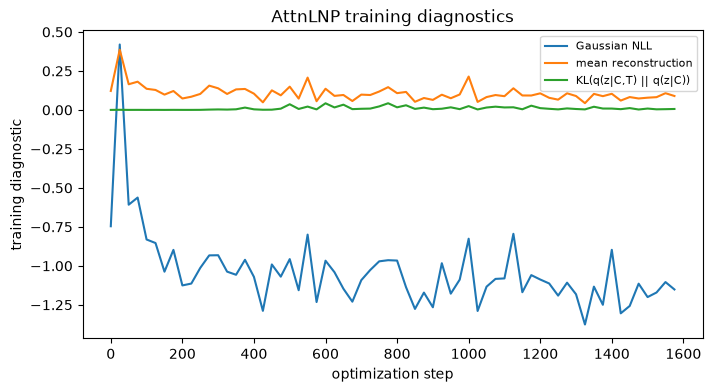

Learned normalized attention locality scale: 0.02991686575114727


In [16]:
# === STABLE FULL ATTLNP FOR A NARROW TRANSIT ===
# Deterministic target-to-context attention + latent prior/posterior.
# Added transit-appropriate inductive biases are stated explicitly above.

class StableTransitAttnLNP(nn.Module):
    def __init__(self, hidden=48, z_dim=12, n_freq=3):
        super().__init__()
        self.hidden = hidden
        self.z_dim = z_dim
        self.n_freq = n_freq

        pos_dim = 1 + 2*n_freq

        self.context_token = nn.Sequential(
            nn.Linear(pos_dim + 1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU()
        )
        self.query_net = nn.Sequential(
            nn.Linear(pos_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden)
        )
        self.key_net = nn.Linear(hidden, hidden)
        self.value_net = nn.Linear(hidden, hidden)

        # Learned locality scale for the attention bias.
        self.log_attn_ell = nn.Parameter(torch.tensor(math.log(0.10), dtype=torch.float32))

        self.latent_token = nn.Sequential(
            nn.Linear(pos_dim + 1, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU()
        )
        self.latent_stats = nn.Sequential(
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2*z_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(pos_dim + hidden + z_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, 2)
        )

    def _pos(self, x):
        feats = [x.unsqueeze(-1)]
        for k in range(self.n_freq):
            f = (2.0**k) * math.pi
            feats += [torch.sin(f*x).unsqueeze(-1), torch.cos(f*x).unsqueeze(-1)]
        return torch.cat(feats, dim=-1)

    def _latent_distribution(self, x, y):
        token = self.latent_token(
            torch.cat([self._pos(x), y.unsqueeze(-1)], dim=-1)
        )
        pooled = token.mean(dim=1)
        stats = self.latent_stats(pooled)
        mu, raw_sigma = stats.chunk(2, dim=-1)
        sigma = 0.05 + F.softplus(raw_sigma)
        return mu, sigma

    def _deterministic_representation(self, x_context, y_context, x_target):
        c = self.context_token(
            torch.cat([self._pos(x_context), y_context.unsqueeze(-1)], dim=-1)
        )
        q = self.query_net(self._pos(x_target))
        k = self.key_net(c)
        v = self.value_net(c)

        logits = torch.matmul(q, k.transpose(1, 2)) / math.sqrt(self.hidden)

        # Transit-appropriate local bias: nearby context points are preferred,
        # while learned content similarity can still reweight them.
        ell = torch.exp(self.log_attn_ell).clamp(0.025, 0.30)
        dist = (x_target[:, :, None] - x_context[:, None, :]) / ell
        logits = logits - 0.5 * dist**2

        attn = torch.softmax(logits, dim=-1)
        r = torch.matmul(attn, v)
        return r, attn, ell

    def _decode(self, x_target, r_target, z):
        z_target = z[:, None, :].expand(-1, x_target.shape[1], -1)
        h = torch.cat([self._pos(x_target), r_target, z_target], dim=-1)
        out = self.decoder(h)
        mu = out[..., 0]

        # Bound aleatoric scale so a rare transit cannot be explained only by
        # arbitrarily large sigma. Units here are normalized-flux units.
        sigma = 0.05 + 0.55 * torch.sigmoid(out[..., 1])
        return mu, sigma

    @staticmethod
    def kl_diag_gaussians(mu_q, sig_q, mu_p, sig_p):
        return (
            torch.log(sig_p / sig_q)
            + (sig_q**2 + (mu_q-mu_p)**2) / (2*sig_p**2)
            - 0.5
        ).sum(dim=-1)

    def forward_train(self, x_context, y_context, x_target, y_target):
        r, attn, ell = self._deterministic_representation(
            x_context, y_context, x_target
        )

        mu_c, sig_c = self._latent_distribution(x_context, y_context)

        # q(z|C,T): concatenate context and target sets explicitly.
        x_post = torch.cat([x_context, x_target], dim=1)
        y_post = torch.cat([y_context, y_target], dim=1)
        mu_ct, sig_ct = self._latent_distribution(x_post, y_post)

        eps = torch.randn_like(mu_ct)
        z = mu_ct + sig_ct * eps
        mu, sigma = self._decode(x_target, r, z)

        return mu, sigma, attn, ell, (mu_c, sig_c, mu_ct, sig_ct)

    @torch.no_grad()
    def predict_from_context(self, x_context, y_context, x_target, n_z=48):
        r, attn, ell = self._deterministic_representation(
            x_context, y_context, x_target
        )
        mu_c, sig_c = self._latent_distribution(x_context, y_context)

        sample_means = []
        sample_vars = []
        for _ in range(n_z):
            z = mu_c + sig_c * torch.randn_like(mu_c)
            mu, sigma = self._decode(x_target, r, z)
            sample_means.append(mu)
            sample_vars.append(sigma**2)

        sample_means = torch.stack(sample_means, dim=0)
        sample_vars = torch.stack(sample_vars, dim=0)

        predictive_mean = sample_means.mean(dim=0)
        predictive_var = (
            (sample_vars + sample_means**2).mean(dim=0)
            - predictive_mean**2
        ).clamp_min(1e-6)

        return (
            predictive_mean,
            torch.sqrt(predictive_var),
            attn,
            mu_c,
            sig_c,
            sample_means,
            ell
        )


def _attnlnp_context(idx, rng, n_context=96):
    # More event points than the ConvCNP exercise are admitted here so the
    # attentive model has enough direct evidence to learn a sharp local relation.
    mask = _np['mask'][idx].astype(bool)
    inside = np.where(mask)[0]
    outside = np.where(~mask)[0]

    chosen = []
    if _labels[idx] >= 2 and len(inside):
        n_in = min(16, len(inside))
        chosen.extend(rng.choice(inside, size=n_in, replace=False).tolist())

    remaining = n_context - len(chosen)
    chosen.extend(rng.choice(outside, size=remaining, replace=False).tolist())
    return np.array(sorted(chosen))


torch.manual_seed(13)
rng_attnlnp = np.random.default_rng(13)
attnlnp = StableTransitAttnLNP(hidden=48, z_dim=12, n_freq=3)
attnlnp_optimizer = torch.optim.Adam(attnlnp.parameters(), lr=1.5e-3)

attnlnp_history = []
attnlnp_start = _time.time()

for step in range(1600):
    batch_ids = rng_attnlnp.choice(train_ids, size=8, replace=True)

    xc, yc, xt, yt = [], [], [], []
    for idx in batch_ids:
        ci = _attnlnp_context(idx, rng_attnlnp)
        xc.append(_tn[idx, ci])
        yc.append(_yn[idx, ci])
        xt.append(_tn[idx])
        yt.append(_yn[idx])

    xc = torch.stack(xc)
    yc = torch.stack(yc)
    xt = torch.stack(xt)
    yt = torch.stack(yt)

    mu, sigma, attn, attn_ell, latent = attnlnp.forward_train(
        xc, yc, xt, yt
    )

    # Rare transit samples receive more weight in this controlled simulation.
    weight = torch.ones_like(yt)
    for b, idx in enumerate(batch_ids):
        m = torch.tensor(_np['mask'][idx].astype(bool))
        weight[b, m] = 12.0

    gaussian_nll = (
        weight * (0.5*((yt-mu)/sigma)**2 + torch.log(sigma))
    ).sum() / weight.sum()

    # Mean-focused auxiliary loss prevents the model from explaining a deep
    # localized event only through a broad predictive sigma.
    mean_loss = (
        weight * F.smooth_l1_loss(mu, yt, reduction='none', beta=0.25)
    ).sum() / weight.sum()

    mu_c, sig_c, mu_ct, sig_ct = latent
    kl = attnlnp.kl_diag_gaussians(mu_ct, sig_ct, mu_c, sig_c).mean()

    # Gentle KL warm-up. Divide by z_dim so beta is easier to interpret.
    beta = min(0.02, 0.02 * step / 400)
    loss = gaussian_nll + 0.35*mean_loss + beta*(kl/attnlnp.z_dim)

    attnlnp_optimizer.zero_grad()
    loss.backward()
    torch.nn.utils.clip_grad_norm_(attnlnp.parameters(), 5.0)
    attnlnp_optimizer.step()

    if step % 25 == 0:
        attnlnp_history.append((
            step,
            float(loss.detach()),
            float(gaussian_nll.detach()),
            float(mean_loss.detach()),
            float(kl.detach()),
            float(attn_ell.detach())
        ))

print(
    f'✓ Stable full AttnLNP classroom model trained in '
    f'{_time.time()-attnlnp_start:.1f} s'
)

attnlnp_hist = pd.DataFrame(
    attnlnp_history,
    columns=['step', 'loss', 'Gaussian NLL', 'mean loss', 'KL', 'attention ell']
)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(attnlnp_hist['step'], attnlnp_hist['Gaussian NLL'], label='Gaussian NLL')
ax.plot(attnlnp_hist['step'], attnlnp_hist['mean loss'], label='mean reconstruction')
ax.plot(attnlnp_hist['step'], attnlnp_hist['KL'], label='KL(q(z|C,T) || q(z|C))')
ax.set_xlabel('optimization step')
ax.set_ylabel('training diagnostic')
ax.set_title('AttnLNP training diagnostics')
ax.legend(fontsize=8)
plt.show()

print('Learned normalized attention locality scale:', float(torch.exp(attnlnp.log_attn_ell).detach().clamp(0.025,0.30)))


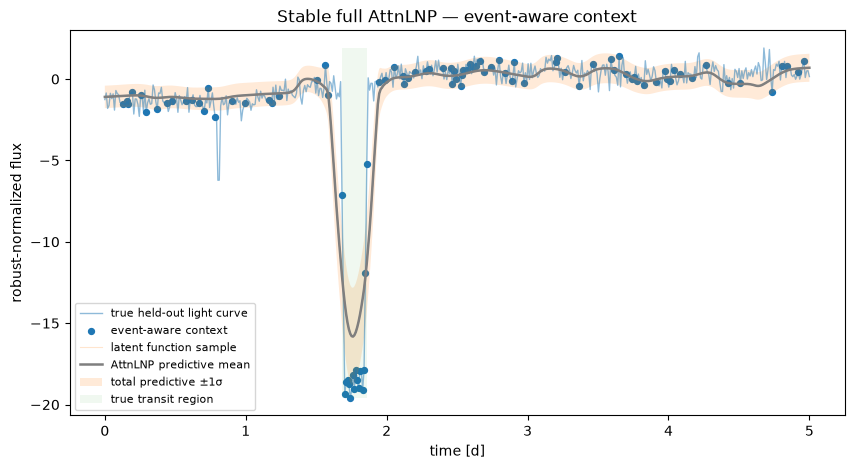

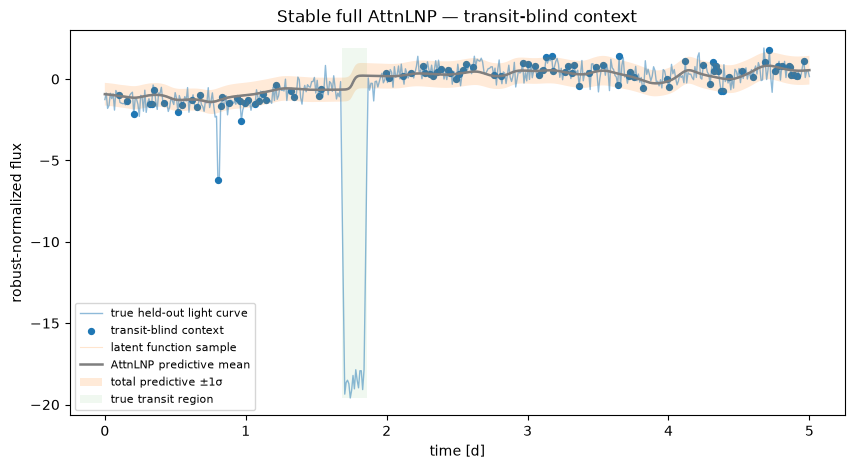

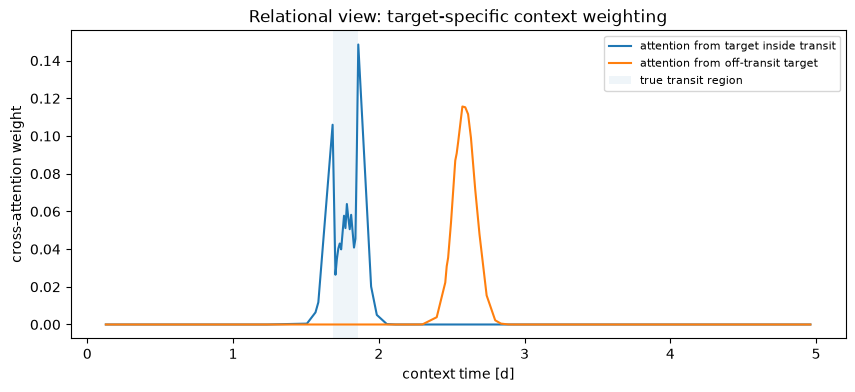

,model,transit RMSE — event-aware,transit RMSE — blind
0,ConvCNP-style,2.598,17.000
1,stable full AttnLNP classroom,3.923,17.001


Latent / predictive uncertainty diagnostics:


,context,mean latent prior sigma,mean predictive sigma in transit
0,event-aware,0.114,2.993
1,transit-blind,0.117,0.763


Attention locality scale (normalized time): 0.02991686575114727
Number of event points in event-aware AttnLNP context: 16


In [17]:
# === HELD-OUT COMPARISON: ConvCNP vs stable full AttnLNP ===
# Reuse the same held-out planet. For the attentive model, construct its own
# event-aware context using the same random seed but up to 16 transit samples.

rng_attn_demo = np.random.default_rng(19)
n_context_attn = 96
n_in_attn = min(16, len(inside))

attn_event_ctx = np.concatenate([
    rng_attn_demo.choice(inside, size=n_in_attn, replace=False),
    rng_attn_demo.choice(outside, size=n_context_attn-n_in_attn, replace=False)
])
attn_event_ctx = np.sort(attn_event_ctx)

# Blind context remains strictly outside the transit plus margin.
attn_blind_ctx = np.sort(
    rng_attn_demo.choice(far_from_event, size=n_context_attn, replace=False)
)


def _attnlnp_predict(context_idx, n_z=48):
    with torch.no_grad():
        pred = attnlnp.predict_from_context(
            _tn[q, context_idx][None, :],
            _yn[q, context_idx][None, :],
            _tn[q][None, :],
            n_z=n_z
        )

    mean, sig, attn, mu_z, sig_z, sample_means, ell = pred
    return (
        mean[0].numpy() * Y_SCALE,
        sig[0].numpy() * Y_SCALE,
        attn[0].numpy(),
        mu_z[0].numpy(),
        sig_z[0].numpy(),
        sample_means[:, 0].numpy() * Y_SCALE,
        float(ell)
    )

(
    mu_attn_event, sig_attn_event, attn_event,
    zmu_event, zsig_event, samples_event, ell_event
) = _attnlnp_predict(attn_event_ctx)

(
    mu_attn_blind, sig_attn_blind, attn_blind,
    zmu_blind, zsig_blind, samples_blind, ell_blind
) = _attnlnp_predict(attn_blind_ctx)

# --- Event-aware predictive view ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_plot, y_plot, lw=1, alpha=.5, label='true held-out light curve')
ax.scatter(t_plot[attn_event_ctx], y_plot[attn_event_ctx], s=18,
           label='event-aware context')

for j in range(min(6, samples_event.shape[0])):
    ax.plot(t_plot, samples_event[j], lw=.8, alpha=.20,
            label='latent function sample' if j == 0 else None)

ax.plot(t_plot, mu_attn_event, lw=1.8,
        label='AttnLNP predictive mean')
ax.fill_between(
    t_plot,
    mu_attn_event-sig_attn_event,
    mu_attn_event+sig_attn_event,
    alpha=.16,
    label='total predictive ±1σ'
)
ax.fill_between(t_plot, y_plot.min(), y_plot.max(),
                where=truth_mask, alpha=.07, label='true transit region')
ax.set_xlabel('time [d]')
ax.set_ylabel('robust-normalized flux')
ax.set_title('Stable full AttnLNP — event-aware context')
ax.legend(fontsize=8)
plt.show()

# --- Transit-blind predictive view ---
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_plot, y_plot, lw=1, alpha=.5, label='true held-out light curve')
ax.scatter(t_plot[attn_blind_ctx], y_plot[attn_blind_ctx], s=18,
           label='transit-blind context')

for j in range(min(6, samples_blind.shape[0])):
    ax.plot(t_plot, samples_blind[j], lw=.8, alpha=.20,
            label='latent function sample' if j == 0 else None)

ax.plot(t_plot, mu_attn_blind, lw=1.8,
        label='AttnLNP predictive mean')
ax.fill_between(
    t_plot,
    mu_attn_blind-sig_attn_blind,
    mu_attn_blind+sig_attn_blind,
    alpha=.16,
    label='total predictive ±1σ'
)
ax.fill_between(t_plot, y_plot.min(), y_plot.max(),
                where=truth_mask, alpha=.07, label='true transit region')
ax.set_xlabel('time [d]')
ax.set_ylabel('robust-normalized flux')
ax.set_title('Stable full AttnLNP — transit-blind context')
ax.legend(fontsize=8)
plt.show()

# --- Target-to-context attention relation ---
inside_idx = np.where(truth_mask)[0]
transit_target = int(inside_idx[len(inside_idx)//2])
far_targets = np.where(~truth_mask)[0]
off_target = int(far_targets[len(far_targets)//2])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_plot[attn_event_ctx], attn_event[transit_target],
        label='attention from target inside transit')
ax.plot(t_plot[attn_event_ctx], attn_event[off_target],
        label='attention from off-transit target')
ax.axvspan(t_plot[inside_idx.min()], t_plot[inside_idx.max()],
           alpha=.07, label='true transit region')
ax.set_xlabel('context time [d]')
ax.set_ylabel('cross-attention weight')
ax.set_title('Relational view: target-specific context weighting')
ax.legend(fontsize=8)
plt.show()

# --- Quantitative comparison ---
true_event_flux = y_plot[truth_mask]

rmse_conv_event = np.sqrt(np.mean((mu_event[truth_mask] - true_event_flux)**2))
rmse_conv_blind = np.sqrt(np.mean((mu_blind[truth_mask] - true_event_flux)**2))
rmse_attn_event = np.sqrt(np.mean((mu_attn_event[truth_mask] - true_event_flux)**2))
rmse_attn_blind = np.sqrt(np.mean((mu_attn_blind[truth_mask] - true_event_flux)**2))

np_compare = pd.DataFrame({
    'model': ['ConvCNP-style', 'stable full AttnLNP classroom'],
    'transit RMSE — event-aware': [rmse_conv_event, rmse_attn_event],
    'transit RMSE — blind': [rmse_conv_blind, rmse_attn_blind],
})

display(np_compare.style.format({
    'transit RMSE — event-aware': '{:.3f}',
    'transit RMSE — blind': '{:.3f}',
}))

latent_summary = pd.DataFrame({
    'context': ['event-aware', 'transit-blind'],
    'mean latent prior sigma': [float(np.mean(zsig_event)), float(np.mean(zsig_blind))],
    'mean predictive sigma in transit': [
        float(np.mean(sig_attn_event[truth_mask])),
        float(np.mean(sig_attn_blind[truth_mask]))
    ]
})

print('Latent / predictive uncertainty diagnostics:')
display(latent_summary.style.format({
    'mean latent prior sigma': '{:.3f}',
    'mean predictive sigma in transit': '{:.3f}',
}))

print('Attention locality scale (normalized time):', ell_event)
print('Number of event points in event-aware AttnLNP context:', n_in_attn)


### Task 4E — interrogate the full AttnLNP

1. Compare the **event-aware** and **transit-blind** posterior-predictive families. Does the model invent a unique transit when object-specific evidence is absent?  
2. Compare the attention profiles for a target **inside** and **outside** transit. Which context points receive weight, and why is this a computational relation rather than automatically a causal physical relation?  
3. What does sampling \(z\sim q(z\mid C)\) add that deterministic attention alone cannot provide?  
4. Does the quoted predictive \(\sigma\) behave exactly as your scientific intuition expects? If not, what checks would you add for calibration?  
5. If the KL term becomes nearly zero, what failure mode might that indicate (**posterior collapse / latent under-use**)? How would you diagnose it?  
6. For PLATO, which additional context token would you add first: uncertainty, camera identity, cadence flag, stellar activity indicator, centroid information, or another diagnostic? Defend the choice.

### Co-intelligence interpretation

ConvCNP and AttnLNP do not create information that was never observed:

\[
\boxed{\text{attention selects relations; the latent path represents uncertainty; neither manufactures missing photons.}}
\]

When the two models disagree, the scientific question is not simply **“which model wins?”** It is:

> **Which representation used different evidence, what assumption caused the disagreement, and what new observation would resolve it?**

> **YOUR ANSWER:**  
>


# Exercise 5 — Blind mission board: only **five follow-up slots** **[10 min]**

Now integrate everything.

You have 12 candidates with:
- BLS periodic evidence;
- PANOPTICON-inspired local event score;
- **PLATO multi-diagnostic vetter score** (5-fold out-of-fold);
- activity/noise and stellar context.

You may select only **five** objects.

For each selected candidate, request **one** new information source with the highest expected scientific information gain:

- another transit epoch;
- RV;
- colour dependence;
- centroid / difference-image equivalent;
- stellar activity indicator;
- higher cadence;
- or another well-justified diagnostic.

The goal is not maximum classification accuracy. It is a **decision under constrained observing resources**.

Look especially for **disagreement**:
- strong BLS but low multi-diagnostic vetter score;
- strong local morphology but low multi-diagnostic score;
- weak BLS but high local/multi-diagnostic support.

Those disagreements are not inconveniences — they identify where another observation may be most valuable.


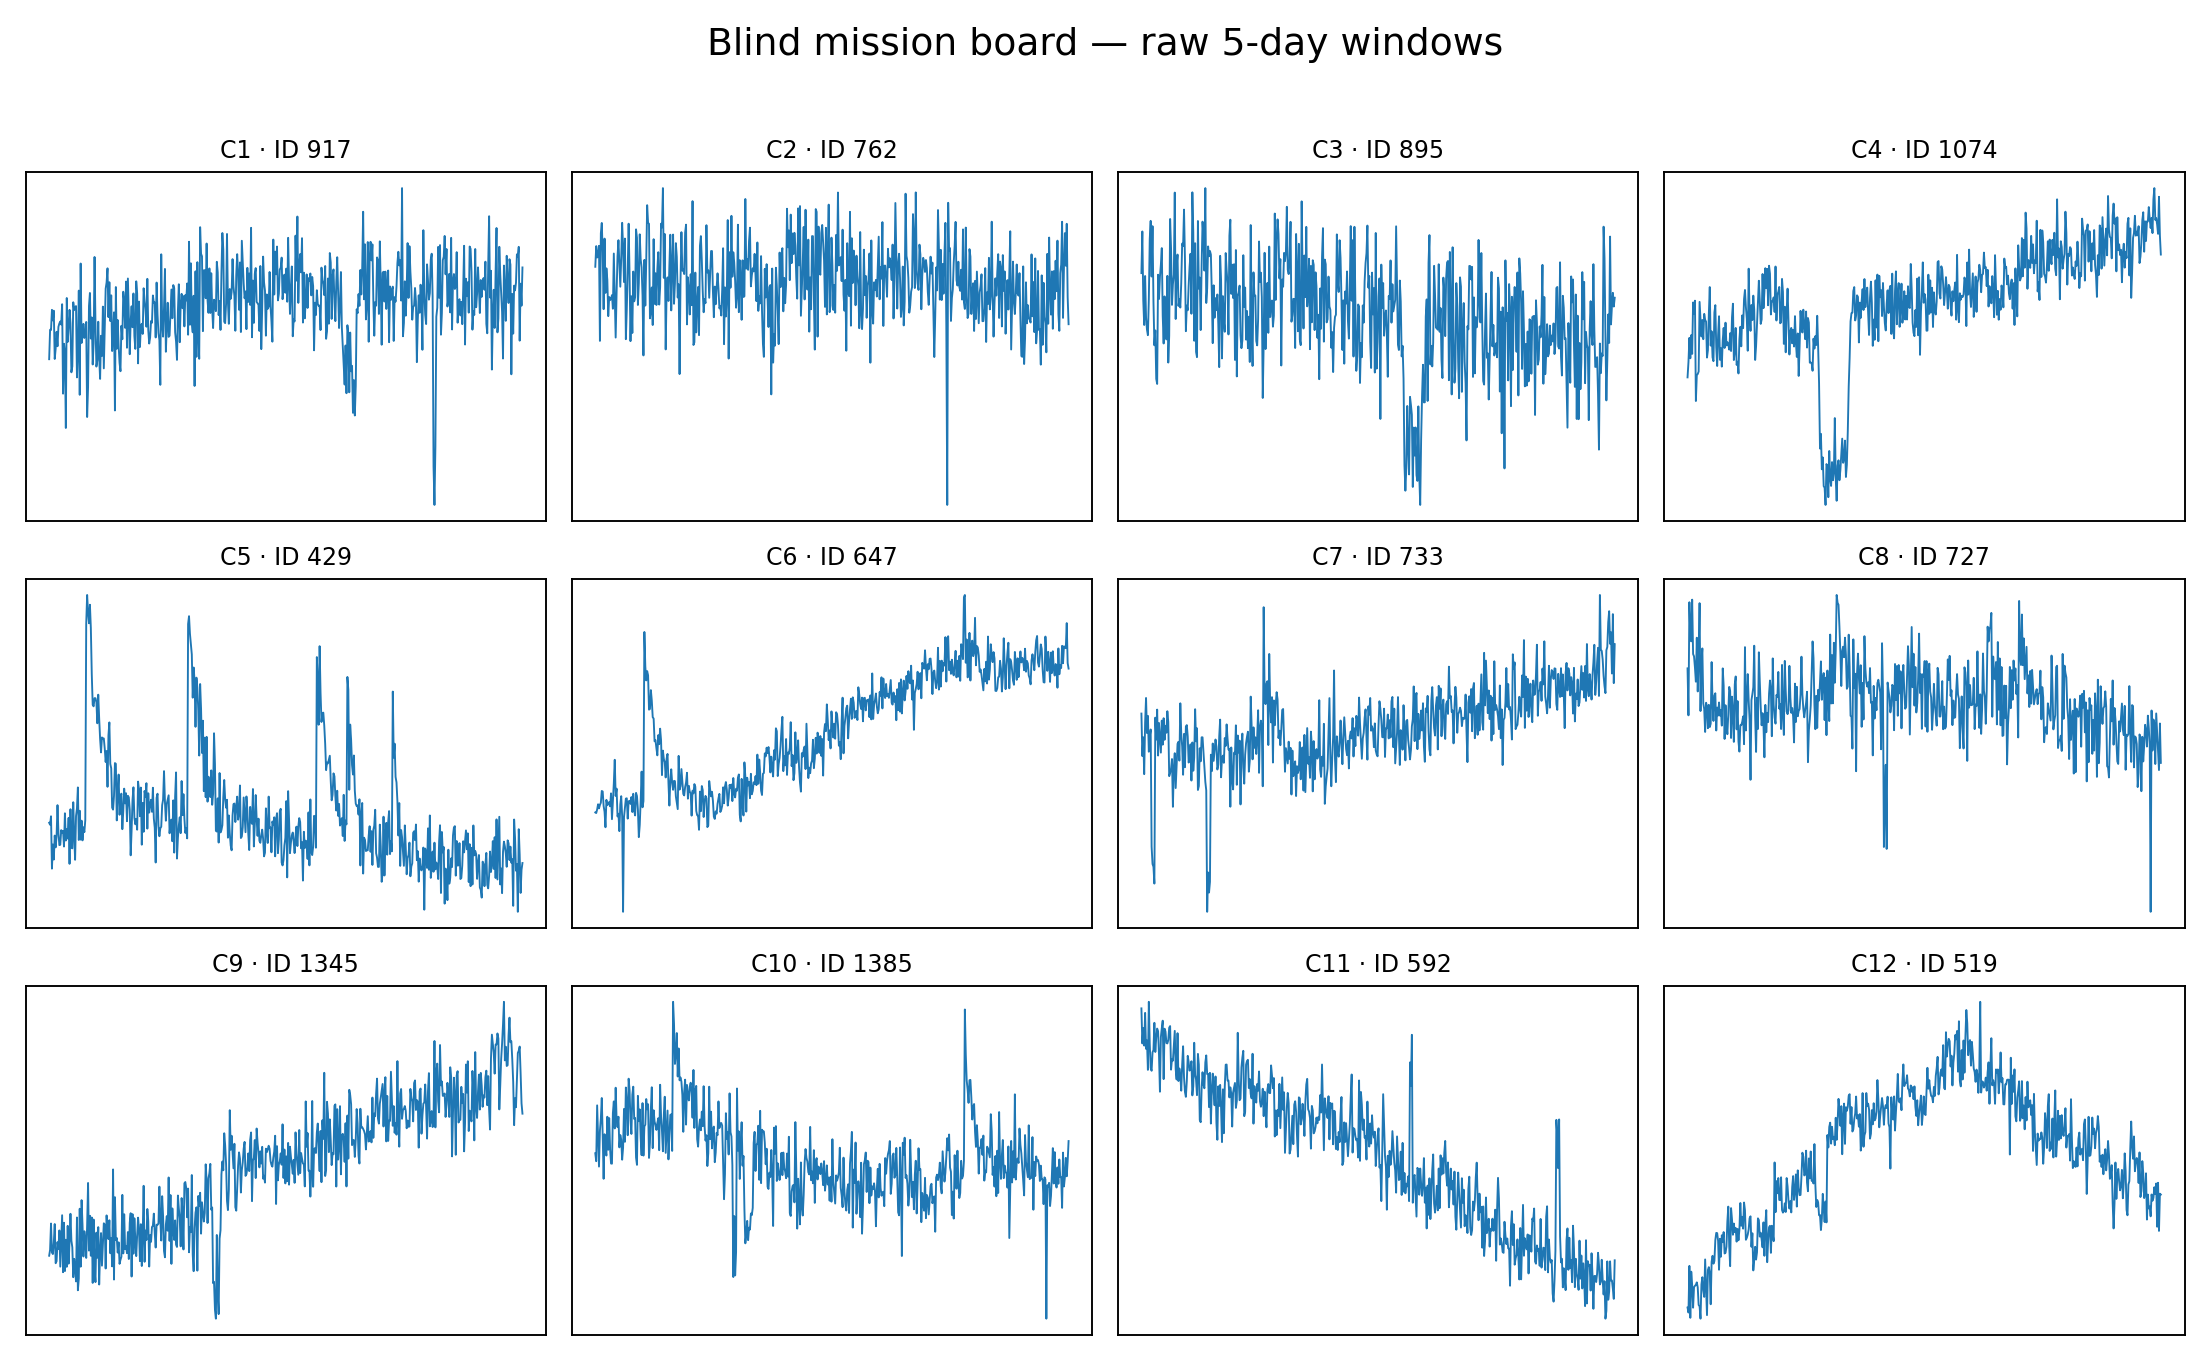

,file_id,bls_power_ratio,bls_period,bls_depth_ppm,panopticon_event_score,act_rms,rotation_period_days,sigma_ppm,teff,logg,plato_vetter_score
0,917,5.56,6.146404,33.742376,0.963,50.6,28.340000,13.6,5818.600000,4.228000,0.948
1,762,5.00,8.677454,38.000089,0.867,73.7,26.880000,35.4,5216.800000,4.237000,0.975
2,895,0.82,34.432533,51.603721,0.999,46.2,20.020000,24.4,6141.100000,4.410000,0.874
3,1074,0.88,1.969961,13.069363,0.999,65.9,30.360000,6.8,5875.900000,4.223000,0.279
4,429,113.09,0.541281,34.962403,0.786,429.8,11.820000,98.9,5549.700000,4.300000,0.967
5,647,60.62,0.694681,28.998369,0.306,537.4,14.030000,72.0,5973.500000,4.396000,0.242
6,733,1.11,0.555714,3.275949,0.968,137.9,18.960000,25.3,5237.500000,4.220000,0.134
7,727,3.26,0.542871,5.949940,0.944,219.0,18.580000,85.0,5924.800000,4.533000,0.055
8,1345,1535.38,4.446997,581.510960,0.589,495.8,19.950000,102.0,5430.900000,4.524000,0.999
9,1385,625.17,4.111513,357.915082,0.679,343.0,15.470000,83.6,6189.300000,4.526000,0.998


In [18]:
_board_img = ASSET_DIR / 'mission_board.png'
if _board_img.exists():
    ipydisplay(Image(filename=str(_board_img), width=1000))

board = pd.read_csv(DATA_DIR / 'challenge_candidates.csv')
board['file_id'] = board['file_id'].astype(int)

# Add the classroom PLATO vetter if Exercise 3B has been run.
if 'plato_vetter_output' in globals():
    board = board.merge(plato_vetter_output, on='file_id', how='left')
else:
    print('⚠ PLATO vetter scores are not available yet. Run Exercise 3B first.')

fmt = {
    'bls_power_ratio': '{:.2f}',
    'panopticon_event_score': '{:.3f}',
    'act_rms': '{:.1f}',
    'sigma_ppm': '{:.1f}',
}
if 'plato_vetter_score' in board.columns:
    fmt['plato_vetter_score'] = '{:.3f}'

display(board.style.format(fmt))


In [19]:
# === GROUP DECISION: EDIT THIS CELL ===
# Put exactly five file IDs in the list.
selected_file_ids = []

# For each selected ID, state ONE requested follow-up source.
# Example only: {123: 'RV', 456: 'another transit epoch'}
requested_information = {}

# Give one sentence of rationale per selected target.
# Example only: {123: 'Strong morphology but ambiguous periodic evidence.'}
rationale = {}

print('Selected:', selected_file_ids)
print('Number selected:', len(selected_file_ids))

if len(selected_file_ids) != 5:
    print('⚠ Mission rule: select exactly five.')

missing_followup = [
    fid for fid in selected_file_ids
    if fid not in requested_information
]
missing_rationale = [
    fid for fid in selected_file_ids
    if fid not in rationale
]

if missing_followup:
    print('⚠ Missing follow-up request for:', missing_followup)
if missing_rationale:
    print('⚠ Missing rationale for:', missing_rationale)


Selected: []
Number selected: 0
⚠ Mission rule: select exactly five.


### Mission-board questions

1. Did you prioritize **agreement** between BLS and event morphology, or **disagreement** that could yield high information gain?
2. Which selected target has the largest epistemic uncertainty?
3. Which follow-up measurement would most directly distinguish **planet** from **stellar/instrumental false positive**?
4. Would ExoMiner++-style diagnostics change your ranking if analogous PLATO diagnostics existed?

> **GROUP ANSWER:**  
>

# Final synthesis — **3 min**

The methods are **not interchangeable classifiers**:

| Method | Representation | Relation preserved | Typical output |
|---|---|---|---|
| BLS | periodic box template | phase-coherent repetition | period / detection statistic |
| PANOPTICON-inspired U-Net3+ | local multi-scale feature map | event morphology across scales | point-wise event probability |
| **PLATO multi-diagnostic vetter** | fused BLS + morphology + activity/noise + period/rotation + stellar context | relations among available PLATO diagnostic views | classroom OOF vetting score |
| **official ExoMiner++ case study** | multiple TESS/SPOC diagnostic branches | relations among independent production-vetting views | official TESS planet-vetting score |
| ConvCNP-style NP | local functional context representation | local context–target structure | conditional function prediction + support |
| **full AttnLNP classroom model** | target-specific cross-attention + latent global state | explicit target–context relations + stochastic function uncertainty | posterior-predictive family + attention map |

The lab deliberately separates a **transferable scientific idea** from a **non-transferable trained survey model**:

\[
\text{ExoMiner philosophy: combine diagnostic views}
\quad \neq \quad
\text{apply the TESS ExoMiner++ model to arbitrary light curves}.
\]

A central information-theory constraint is:

\[
I(S;\hat Y\mid D)\le I(S;Z\mid D)\le I(S;X\mid D).
\]

A model can exploit priors learned from \(D\), but it cannot recover object-specific information that the observing operator or representation has already destroyed.

## Exit ticket
Complete in **one sentence**:

> **“A scientifically good latent representation should preserve …”**

**YOUR SENTENCE:**


## References and provenance

- Kovács, Zucker & Mazeh (2002), *A box-fitting algorithm in the search for periodic transits*, A&A 391, 369.
- Vivien et al. (2025), **PANOPTICON: A novel deep learning model to detect single transit events with no prior data filtering in PLATO light curves**, A&A 694, A293, DOI: 10.1051/0004-6361/202452124.  
  **This notebook does not claim to use author code or author weights.**
- Valizadegan et al. (2025), **ExoMiner++: Enhanced Transit Classification and a New Vetting Catalog for 2-Minute TESS Data**, arXiv:2502.09790 / AJ 170.  
  Official software: NASA `nasa/Exominer` repository; official pipeline is intended for TESS/SPOC products.
- Garnelo et al. (2018), **Neural Processes**, arXiv:1807.01622.
- Kim et al. (2019), **Attentive Neural Processes**, arXiv:1901.05761.
- Gordon et al. (2019), **Convolutional Conditional Neural Processes**, arXiv:1910.13556.
- Neural Process Family reproducibility pages used for the architecture discussion: [**ConvCNP**](https://yanndubs.github.io/Neural-Process-Family/reproducibility/ConvCNP.html) and [**AttnLNP**](https://yanndubs.github.io/Neural-Process-Family/reproducibility/AttnLNP.html).
- **AttnLNP implementation in this notebook:** original compact classroom implementation containing the full deterministic-attention + latent-prior/posterior + variational-training structure; it is **not** the authors' released `npf` implementation and its numerical results are not published performance.

- **PLATO multi-diagnostic vetter (this notebook):** original classroom logistic-fusion exercise using BLS, PANOPTICON-inspired, activity/noise, period–rotation, and stellar-context diagnostics. It is **not ExoMiner++** and the reported cross-validated scores are **not a PLATO mission forecast**.

### Reproducibility rule
When presenting results, always label whether a result comes from:
**(i)** the student's simulation/analysis, **(ii)** a classroom reimplementation, **(iii)** an official released pipeline, or **(iv)** a conceptual/model-design exercise.
